# Cross-Play Benchmark

Benchmark of open-weight LLMs on three NegotiationArena games (**Trading**, **Ultimatum**, **BuySell**).

Within each size tier, every ordered pair of distinct models plays 30 games (cross-play only)
(6 ordered pairs × 30 = 180 runs per game × tier × condition). 

Conditions: `no_retries`, `retry3` 

### Metrics

| Concept | Definition |
|---|---|
| **Completed** | game reached `END` (no unrecoverable format failure) |
| **Deal** | completed **and** `final_response == "ACCEPT"`; otherwise both payoffs are set to 0 |
| **Payoff** | Trading: Δ total resources; Ultimatum: dollars obtained (0 if rejected/timeout); BuySell: profit (seller `price − 40`, buyer `60 − price`) |
| **Win** | strictly higher payoff than the opponent; **ties (incl. all no-deals) are excluded from the win-rate denominator** |
| **Payoff-valid** | payoff inside the game's feasible range (Trading ±30, Ultimatum [0,100], BuySell [−40,60]); a handful of hallucinated-amount games are excluded from payoff *means* but kept for win rates |

Families: **Gemma** (4B / 12B / 27B), **Mistral** (Ministral 8B / 14B, Mistral-Small 24B),
**Qwen** (9B / 14B / 27B) across tiers `very_small` / `small` / `medium`.

In [995]:
import sys, os, json, warnings
import matplotlib.patches as mpatches
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_theme(style="ticks", palette="colorblind", font_scale=1.2)
matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                            "legend.frameon": False})
colormap = sns.color_palette("Blues")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZES = ["very_small", "small", "medium"]

In [996]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())


In [997]:
from scipy import stats as sps

GAMES = {"Trading": "trading_section_one",
         "Ultimatum": "ultimatum_section_one",
         "BuySell": "buysell_section_one"}
CONDITIONS = ["retry3", "no_retries"]
FAMILIES = ["Gemma", "Mistral", "Qwen"]
SIZE_LABELS = {"very_small": "Very Small", "small": "Small", "medium": "Medium"}

def model_family(name):
    low = name.lower()
    if low.startswith("gemma"): return "Gemma"
    if low.startswith(("ministral", "mistral")): return "Mistral"
    if low.startswith("qwen"): return "Qwen"
    return "Other"

def _trade_price(trade):
    """ZUP amount of a structured buysell trade proposal (None if absent)."""
    if not isinstance(trade, dict):
        return None
    for side in (trade.get("_value") or {}).values():
        vals = (side or {}).get("_value") or {}
        if "ZUP" in vals:
            try:
                return float(vals["ZUP"])
            except (TypeError, ValueError):
                return None
    return None

def _ult_opening(turn_states):
    """Dollars the proposer (P1 = RED) offers the responder on the opening turn.

    NegotiationArena ultimatum: P1 holds the pot and moves first; the turn-1
    trade lists the dollars each side *gives*, so RED's give-side is the amount
    offered to the responder. None/unparsed openings return NaN.
    """
    if not turn_states:
        return np.nan
    trade = (turn_states[0].get("player_public_info_dict") or {}).get("newly proposed trade")
    if not isinstance(trade, dict):
        return np.nan
    side = (trade.get("_value") or {}).get("RED") or {}
    vals = (side.get("_value") or {})
    if "Dollars" in vals:
        try:
            return float(vals["Dollars"])
        except (TypeError, ValueError):
            return np.nan
    return np.nan

# feasible payoff ranges; BuySell: surplus with price in [0, 100] (the buyer's ZUP)
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}

def _load_run(path, game):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    players = data["players"]
    completed = last.get("current_iteration") == "END"
    turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
    retries = [s.get("parse_retries", 0) for s in turn_states]
    row = dict(
        model_1=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        model_2=clean_name(players[1].get("model_id", players[1].get("model", "?"))),
        completed=completed, num_turns=len(turn_states),
        total_retries=sum(r for r in retries if isinstance(r, int)),
        retries_per_turn=[r if isinstance(r, int) else 0 for r in retries],
        payoff_1=np.nan, payoff_2=np.nan, deal=False, final_response=None,
        price=np.nan, prices=None, ult_open_offer=np.nan, path=path,
    )
    if game == "BuySell":
        # one entry per turn (None when the turn carried no trade); P1=seller moves at even indices
        row["prices"] = [_trade_price((s.get("player_public_info_dict") or {})
                                      .get("newly proposed trade")) for s in turn_states]
    if game == "Ultimatum":
        row["ult_open_offer"] = _ult_opening(turn_states)
    if not completed:
        return row
    s = last["summary"]
    row["final_response"] = str(s.get("final_response"))
    row["deal"] = row["final_response"] == "ACCEPT"
    if game == "Trading":
        init, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(init[0])
        p2 = resource_value(fin[1]) - resource_value(init[1])
    elif game == "Ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # BuySell
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
        if row["deal"] and np.isfinite(p1):
            row["price"] = p1 + 40.0
    if not row["deal"]:
        p1 = p2 = 0.0
    row["payoff_1"], row["payoff_2"] = p1, p2
    return row

_rows = []
for _game, _gdir in GAMES.items():
    for _cond in CONDITIONS:
        for _size in SIZES:
            _dir = os.path.join(LOGS_ROOT, f"section_one/{_gdir}/{_cond}/{_size}")
            for _root, _dirs, _files in os.walk(_dir):
                if "game_state.json" not in _files:
                    continue
                try:
                    r = _load_run(os.path.join(_root, "game_state.json"), _game)
                except Exception:
                    continue
                r.update(game=_game, condition=_cond, size=_size)
                _rows.append(r)

MASTER = pd.DataFrame(_rows)
MASTER["family_1"] = MASTER["model_1"].map(model_family)
MASTER["family_2"] = MASTER["model_2"].map(model_family)
_lo = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_hi = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
MASTER["payoff_valid"] = (MASTER["payoff_1"].between(_lo, _hi)
                          & MASTER["payoff_2"].between(_lo, _hi))

def _winner(r):
    if not r.completed or not np.isfinite(r.payoff_1):
        return "incomplete"
    if r.payoff_1 > r.payoff_2: return "P1"
    if r.payoff_2 > r.payoff_1: return "P2"
    return "tie"
MASTER["winner"] = MASTER.apply(_winner, axis=1)

def model_view(df):
    """Long format: one row per (run, seat) so each game contributes one row per model."""
    a = df.rename(columns={"model_1": "model", "family_1": "family", "model_2": "opponent",
                           "family_2": "opp_family", "payoff_1": "payoff",
                           "payoff_2": "opp_payoff"}).assign(seat="P1")
    b = df.rename(columns={"model_2": "model", "family_2": "family", "model_1": "opponent",
                           "family_1": "opp_family", "payoff_2": "payoff",
                           "payoff_1": "opp_payoff"}).assign(seat="P2")
    out = pd.concat([a, b], ignore_index=True)
    out["win"] = np.where(out["winner"].isin(["P1", "P2"]),
                          (out["winner"] == out["seat"]).astype(float), np.nan)
    return out

RETRY3 = MASTER[MASTER["condition"] == "retry3"].copy()
MV = model_view(RETRY3)

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return centre - half, centre + half

print(MASTER.groupby(["condition", "game"]).size().unstack())
print("\nretry3 not completed:",
      RETRY3.groupby("game")["completed"].apply(lambda s: (~s).sum()).to_dict())
print("retry3 payoff-invalid completed games:",
      len(RETRY3[RETRY3.completed & ~RETRY3.payoff_valid]))
print(RETRY3[RETRY3.completed & ~RETRY3.payoff_valid][["game", "size", "model_1", "model_2", "payoff_1", "payoff_2"]].to_string())

game        BuySell  Trading  Ultimatum
condition                              
no_retries      540      540        540
retry3          540      540        540

retry3 not completed: {'BuySell': 9, 'Trading': 18, 'Ultimatum': 1}
retry3 payoff-invalid completed games: 2
           game        size               model_1         model_2  payoff_1  payoff_2
1161  Ultimatum  very_small   Ministral-3-8B-2512   gemma-3-4b-it     150.0     -50.0
1304  Ultimatum       small  Ministral-3-14B-2512  gemma-3-12b-it     200.0    -100.0


## 1. Completion & format self-correction

Before asking how *well* models negotiate, we need to know how often they produce a **valid** game at all. A run fails when a model emits an unparseable move. This section follows that failure: **how often** it happens, **why**, **which models** cause it, whether a **self-correction loop** repairs it, and **how much** correction it takes.

### How often do games fail?

Completion rate per game and tier **without retries** (pooled over all pairings, 180 runs per bar, Wilson 95% CIs).

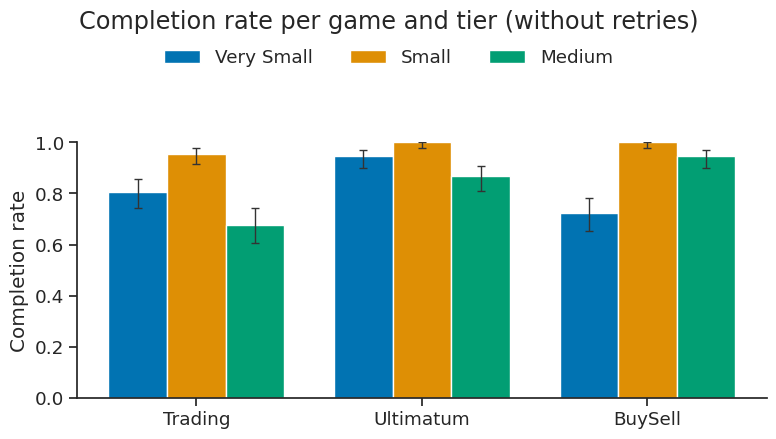

size       very_small  small  medium
game                                
BuySell         0.722  1.000   0.944
Trading         0.806  0.956   0.678
Ultimatum       0.944  1.000   0.867


In [998]:
#  Completion rate by game and tier (no_retries) 
comp_src = MASTER[MASTER["condition"] == "no_retries"]
cc = (comp_src.groupby(["game", "size"])
      .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
cc["rate"] = cc["k"] / cc["n"]
cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

size_pal = dict(zip(SIZES, sns.color_palette("colorblind", 3)))
games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, sz in enumerate(SIZES):
    sub = cc[cc["size"] == sz].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=SIZE_LABELS[sz], color=size_pal[sz])
    ax.errorbar(pos, sub["rate"],
                yerr=[sub["rate"] - sub["lo"], sub["hi"] - sub["rate"]],
                fmt="none", ecolor="0.2", capsize=3, lw=1)
ax.set_xticks(x); ax.set_xticklabels(games)
ax.set_ylabel("Completion rate"); ax.set_ylim(0, 1)
fig.suptitle("Completion rate per game and tier (without retries)")
_h, _l = ax.get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=3, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

print(cc.pivot_table(index="game", columns="size", values="rate")
      .reindex(columns=SIZES).round(3).to_string())

### Table 4.1 - completion by family and tier

Completion rate by game and parameter tier **without retries** (per family and pooled over families
with 95% Wilson CIs) and **with the retry-3** self-correction loop. A game counts toward a family
when one of its models occupies *either* seat, so each cross-play game is credited to both families;
the **All** columns pool over all 180 runs per (game, tier).

In [999]:
#  Table 4.1: completion rate by game x tier -- per family + pooled (Wilson 95% CI),
#  no_retries vs retry-3. A game counts toward a family when one of its models
#  occupies *either* seat, so cross-play games are credited to both families.
TIER_LABEL = {"very_small": "4-9B", "small": "12-14B", "medium": "24-27B"}

def _fam_completion(df, fam):
    sub = df[(df["family_1"] == fam) | (df["family_2"] == fam)]
    return sub["completed"].mean() if len(sub) else np.nan

def _pooled_ci(df):
    k, n = int(df["completed"].sum()), len(df)
    if n == 0:
        return "-"
    lo, hi = wilson_ci(k, n)
    return f"{k / n:.2f} [{lo:.2f},{hi:.2f}]"

_t41 = []
for _game in GAMES:
    for _sz in SIZES:
        _nr = MASTER[(MASTER["condition"] == "no_retries")
                     & (MASTER["game"] == _game) & (MASTER["size"] == _sz)]
        _r3 = MASTER[(MASTER["condition"] == "retry3")
                     & (MASTER["game"] == _game) & (MASTER["size"] == _sz)]
        _t41.append({
            ("", "Game"): _game,
            ("", "Tier"): TIER_LABEL[_sz],
            ("No retries", "Gemma"):   f"{_fam_completion(_nr, 'Gemma'):.2f}",
            ("No retries", "Mistral"): f"{_fam_completion(_nr, 'Mistral'):.2f}",
            ("No retries", "Qwen"):    f"{_fam_completion(_nr, 'Qwen'):.2f}",
            ("No retries", "All"):     _pooled_ci(_nr),
            ("Retry-3", "All"):        _pooled_ci(_r3),
        })

TABLE_41 = pd.DataFrame(_t41)
TABLE_41.columns = pd.MultiIndex.from_tuples(TABLE_41.columns)
TABLE_41 = TABLE_41.set_index([("", "Game"), ("", "Tier")])
TABLE_41.index.names = ["Game", "Tier"]

try:
    display(TABLE_41)
except NameError:
    pass
print("Table 4.1 - Completion rate by game and parameter tier")
#print(TABLE_41.to_string())

No retries                                           Retry-3
                      Gemma Mistral  Qwen               All               All
Game      Tier                                                               
Trading   4-9B         0.82    0.79  0.80  0.81 [0.74,0.86]  0.91 [0.85,0.94]
          12-14B       0.97    0.96  0.93  0.96 [0.91,0.98]  1.00 [0.98,1.00]
          24-27B       0.70    0.74  0.59  0.68 [0.61,0.74]  0.99 [0.97,1.00]
Ultimatum 4-9B         0.97    0.95  0.92  0.94 [0.90,0.97]  0.99 [0.97,1.00]
          12-14B       1.00    1.00  1.00  1.00 [0.98,1.00]  1.00 [0.98,1.00]
          24-27B       0.89    0.82  0.88  0.87 [0.81,0.91]  1.00 [0.98,1.00]
BuySell   4-9B         0.58    0.79  0.79  0.72 [0.65,0.78]  0.95 [0.91,0.97]
          12-14B       1.00    1.00  1.00  1.00 [0.98,1.00]  1.00 [0.98,1.00]
          24-27B       0.96    0.92  0.96  0.94 [0.90,0.97]  1.00 [0.98,1.00]

Table 4.1 - Completion rate by game and parameter tier


### Why do they fail?

Each unrecoverable failure logs the parse error that ended the game. Here we look at the **no-retries (retry0)** condition: the raw failure modes a single malformed move produces before any self-correction (the retry3 survivors are covered in the two beats below). The by-condition table further down contrasts retry0 with retry3.

In [1000]:
import re

def error_reason(msg):
    msg = msg or ""
    m = re.match(r"Missing required tag: <([^>]+)>", msg)
    if m:
        tag = m.group(1)
        return (f"missing tag <{tag}>" if tag in ("player answer", "my resources", "MOVE")
                else "missing tag (other)")
    if msg.startswith("Trade must have exactly two players"):
        return "malformed trade line (no '|')"
    if msg.startswith("Could not parse resource"):
        return "unparseable resource amount"
    return "other (lookup error)"

fail_rows = []
for _game, _gdir in GAMES.items():
    for _cond in CONDITIONS:
        for _root, _dirs, _files in os.walk(os.path.join(LOGS_ROOT, f"section_one/{_gdir}/{_cond}")):
            if "game_state.json" not in _files:
                continue
            with open(os.path.join(_root, "game_state.json")) as f:
                d = json.load(f)
            last = d["game_state"][-1]
            if last.get("current_iteration") == "END":
                continue
            ts = [s for s in d["game_state"] if s.get("current_iteration") not in ("START", "END")]
            who = clean_name(d["players"][(len(ts) - 1) % 2].get("model_id", "?"))
            fail_rows.append({"game": _game, "condition": _cond, "model": who,
                              "family": model_family(who),
                              "reason": error_reason(last.get("error_message"))})
FAILS = pd.DataFrame(fail_rows)
FAILS0 = FAILS[FAILS["condition"] == "no_retries"]  # raw failures, no safety net

counts = FAILS["reason"].value_counts()  # ordering used across the tables

def _with_total(df):
    out = df.copy(); out["total"] = out.sum(axis=1); return out

by_condition = _with_total(FAILS.groupby(["reason", "condition"]).size()
                           .unstack(fill_value=0).reindex(counts.index))
by_game = _with_total(FAILS0.groupby(["reason", "game"]).size()
                      .unstack(fill_value=0).reindex(counts.index).fillna(0)
                      .astype(int)[list(GAMES)])
by_model = FAILS0["model"].value_counts().rename("failures").to_frame()
by_model["family"] = by_model.index.map(model_family)

cap_style = [{"selector": "caption", "props": [("font-weight", "bold"),
              ("text-align", "left"), ("padding-bottom", "4px")]}]
for _df, _cap in [(by_condition, "Game-ending parse errors by reason and condition "
                                 "(retry0 vs retry3)"),
                  (by_game, "No-retry (retry0) failures by reason and game"),
                  (by_model, "No-retry (retry0) failures by model")]:
    display(_df.style.set_caption(_cap).set_table_styles(cap_style))

condition,no_retries,retry3,total
reason,,,
missing tag,58,0,58
unparseable resource amount,33,18,51
malformed trade line (no '|'),43,3,46
missing tag (other),19,5,24
missing tag,22,0,22
missing tag,18,0,18
other (lookup error),2,2,4


game,Trading,Ultimatum,BuySell,total
reason,,,,
missing tag,47,9,2,58
unparseable resource amount,26,3,4,33
malformed trade line (no '|'),3,0,40,43
missing tag (other),9,4,6,19
missing tag,16,0,6,22
missing tag,0,18,0,18
other (lookup error),0,0,2,2


,failures,family
model,,
gemma-3-4b-it,69,Gemma
Qwen3.5-27B,45,Qwen
Mistral-Small-3.2-24B-2506,43,Mistral
Qwen3.5-9B,24,Qwen
Ministral-3-14B-2512,5,Mistral
gemma-3-27b-it,4,Gemma
Qwen3-14B,3,Qwen
Ministral-3-8B-2512,2,Mistral


**What actually breaks**, by reason and game, **without retries (retry0)**: each bar is a game-ending parse error, colored by the game it occurred in. Trading drives the missing `<player answer>` and unparseable-resource errors, BuySell the malformed trade line, Ultimatum the missing `<MOVE>`.

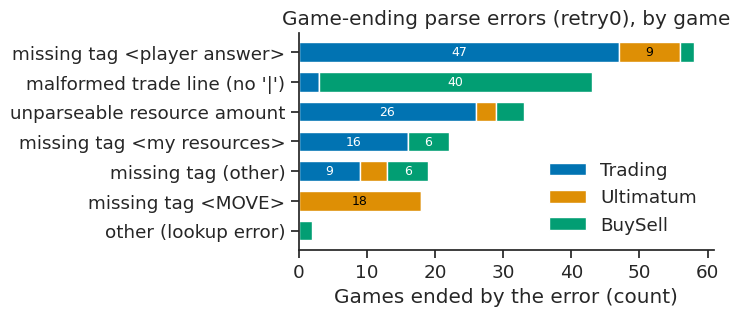

In [1001]:
#  Which game each failure mode comes from 
by_game = (FAILS0.groupby(["reason", "game"]).size().unstack(fill_value=0)
           .reindex(columns=list(GAMES)))
by_game = by_game.loc[by_game.sum(1).sort_values(ascending=False).index]

game_pal = dict(zip(GAMES, sns.color_palette("colorblind", 3)))
txt = {"Trading": "white", "Ultimatum": "black", "BuySell": "white"}
fig, ax = plt.subplots(figsize=(7.5, 3.4))
left = np.zeros(len(by_game))
for g in GAMES:
    vals = by_game[g].values
    ax.barh(by_game.index, vals, left=left, color=game_pal[g], label=g, height=0.65)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v >= 6:
            ax.text(l + v / 2, y, str(v), ha="center", va="center",
                    fontsize=9, color=txt[g])
    left += vals
ax.invert_yaxis()
ax.set_xlabel("Games ended by the error (count)")
ax.legend(loc="lower right")
ax.set_title('Game-ending parse errors (retry0), by game')
fig.tight_layout(); plt.show()

### Which models cause them?

The same **no-retry (retry0)** failures attributed to the model that emitted the fatal move. Format fragility is far from uniform across the nine models.

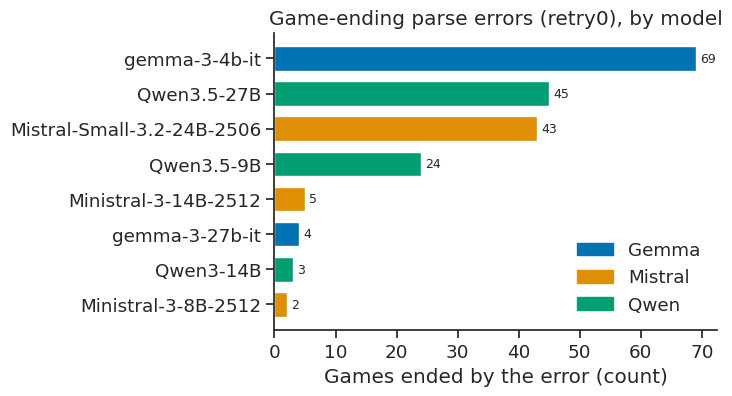

                     model  family  failures
             gemma-3-4b-it   Gemma        69
               Qwen3.5-27B    Qwen        45
Mistral-Small-3.2-24B-2506 Mistral        43
                Qwen3.5-9B    Qwen        24
      Ministral-3-14B-2512 Mistral         5
            gemma-3-27b-it   Gemma         4
                 Qwen3-14B    Qwen         3
       Ministral-3-8B-2512 Mistral         2


In [1002]:
fam_pal = dict(zip(FAMILIES, sns.color_palette("colorblind", 3)))
mc = (FAILS0.groupby(["model", "family"]).size()
      .reset_index(name="failures").sort_values("failures", ascending=False))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(mc["model"], mc["failures"],
        color=[fam_pal[f] for f in mc["family"]], height=0.7)
ax.bar_label(ax.containers[0], fontsize=9, padding=3)
ax.invert_yaxis()
ax.set_xlabel("Games ended by the error (count)")
handles = [mpatches.Patch(color=fam_pal[f], label=f) for f in FAMILIES]
ax.legend(handles=handles, loc="lower right")
ax.set_title('Game-ending parse errors (retry0), by model')
fig.tight_layout(); plt.show()

print(mc.to_string(index=False))

### Does a retry loop help?

The self-correction loop lets a model re-emit a move up to three times. Completion with vs without that budget, grouped by tier (`r=0` vs `r=3`), then as the per-game slope for each tier. Three retries pull every cell to ≈1.0: the no-retry dips are format failures, not models that cannot finish a negotiation.

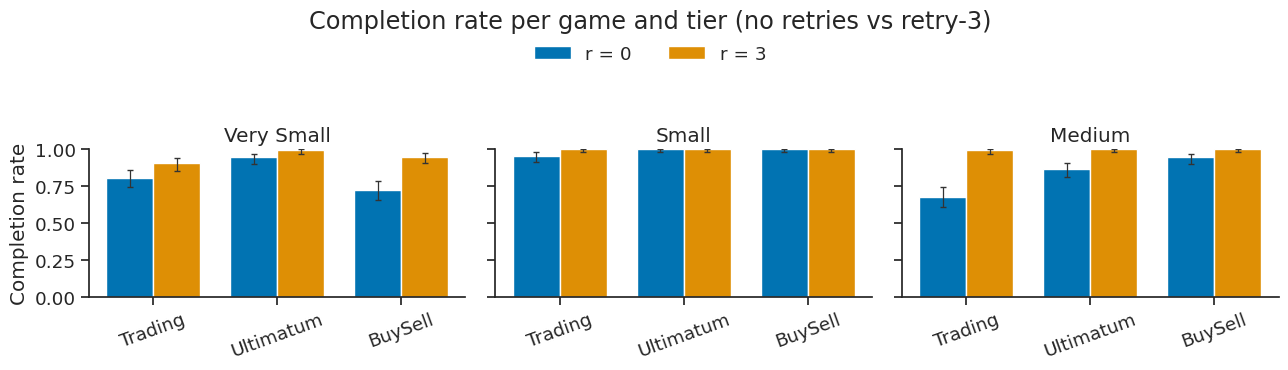

In [1003]:
#  Completion: r=0 vs r=3, by game, faceted by tier 
rec = (MASTER.groupby(["size", "condition", "game"])
       .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
rec["rate"] = rec["k"] / rec["n"]
rec[["lo", "hi"]] = rec.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

cond_pal = {"no_retries": sns.color_palette("colorblind")[0],
            "retry3": sns.color_palette("colorblind")[1]}
cond_lbl = {"no_retries": "r = 0", "retry3": "r = 3"}
games = list(GAMES); x = np.arange(len(games)); width = 0.38
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, sz in zip(axes, SIZES):
    for j, cond in enumerate(["no_retries", "retry3"]):
        sub = rec[(rec["size"] == sz) & (rec["condition"] == cond)].set_index("game").reindex(games)
        pos = x + (j - 0.5) * width
        ax.bar(pos, sub["rate"], width, label=cond_lbl[cond], color=cond_pal[cond])
        ax.errorbar(pos, sub["rate"],
                    yerr=[sub["rate"] - sub["lo"], sub["hi"] - sub["rate"]],
                    fmt="none", ecolor="0.2", capsize=2, lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels(games, rotation=20)
    ax.set_title(SIZE_LABELS[sz])
axes[0].set_ylabel("Completion rate"); axes[0].set_ylim(0, 1)
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=2, frameon=False)
fig.suptitle("Completion rate per game and tier (no retries vs retry-3)")
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

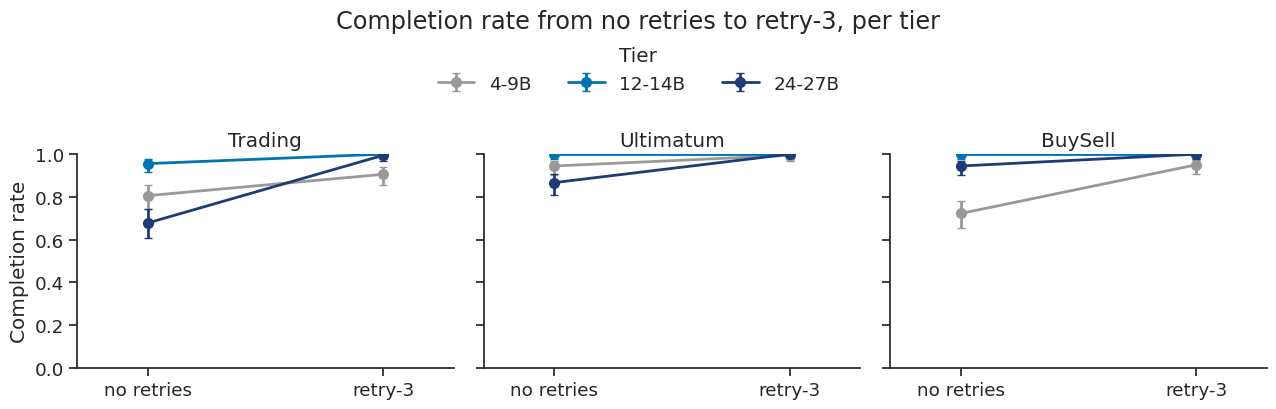

In [1004]:
#  Completion: no-retries -> retry-3 slope, per tier, faceted by game 
TIER_B = {"very_small": "4-9B", "small": "12-14B", "medium": "24-27B"}
tier_pal = {"very_small": "0.6", "small": sns.color_palette("colorblind")[0], "medium": "#1f3b73"}
order = ["no_retries", "retry3"]; xt = [0, 1]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, game in zip(axes, GAMES):
    for sz in SIZES:
        sub = (rec[(rec["game"] == game) & (rec["size"] == sz)]
               .set_index("condition").reindex(order))
        ax.errorbar(xt, sub["rate"],
                    yerr=[sub["rate"] - sub["lo"], sub["hi"] - sub["rate"]],
                    marker="o", ms=7, lw=2, capsize=3,
                    color=tier_pal[sz], label=TIER_B[sz])
    ax.set_xticks(xt); ax.set_xticklabels(["no retries", "retry-3"])
    ax.set_xlim(-0.3, 1.3); ax.set_title(game)
axes[0].set_ylabel("Completion rate"); axes[0].set_ylim(0, 1)
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=3,
           title="Tier", frameon=False)
fig.suptitle("Completion rate from no retries to retry-3, per tier")
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

### How much correction does it take?

Among the moves that actually triggered the loop: how often a retry is needed, where the move finally parses, and the share of triggered moves the budget resolves.

Completion rate (game level, pooled over models):
size                  very_small  small  medium
condition  game                                
no_retries BuySell         0.722  1.000   0.944
           Trading         0.806  0.956   0.678
           Ultimatum       0.944  1.000   0.867
retry3     BuySell         0.950  1.000   1.000
           Trading         0.906  1.000   0.994
           Ultimatum       0.994  1.000   1.000


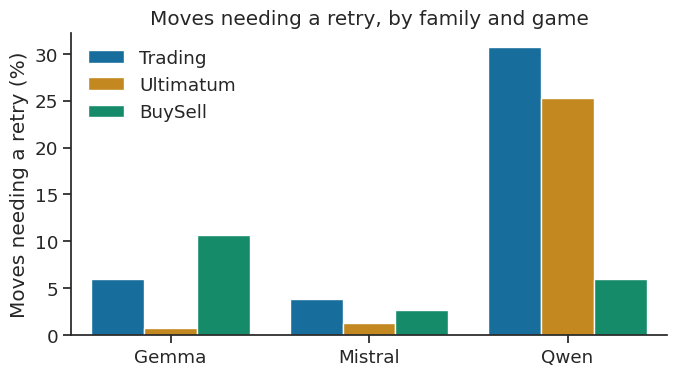


Retried moves by family x game (counts):
game     BuySell  Trading  Ultimatum
family                              
Gemma         57       31          3
Mistral       14       20          5
Qwen          30      158         96


In [1005]:
#  Self-correction: how often is a retry needed? 
_mvall = model_view(MASTER)
comp = (_mvall.groupby(["condition", "game", "size"])["completed"].mean()
        .unstack("size").reindex(columns=SIZES).round(3))
print("Completion rate (game level, pooled over models):")
print(comp.to_string())

# incomplete games end in an ERROR state whose retries are not recorded: the move burned the
# whole budget and still failed (all 28 are parse errors), so count it as 3 retries + failure
turn_rows = []
for _, r in RETRY3.iterrows():
    rpt = r["retries_per_turn"]
    for t, k in enumerate(rpt):
        who = r["model_1"] if t % 2 == 0 else r["model_2"]
        failed = (not r["completed"]) and (t == len(rpt) - 1)
        turn_rows.append({"game": r["game"], "size": r["size"], "model": who,
                          "family": model_family(who), "turn": t + 1,
                          "retries": 3 if failed else k, "failed": failed})
TURNS = pd.DataFrame(turn_rows)

# % of moves needing at least one retry, by family and game
rate = (TURNS.assign(retried=TURNS["retries"] > 0)
        .groupby(["family", "game"])["retried"].mean().mul(100).reset_index())
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(rate, x="family", y="retried", hue="game", order=FAMILIES,
            hue_order=list(GAMES), ax=ax)
ax.set_xlabel(None); ax.set_ylabel("Moves needing a retry (%)")
ax.legend(loc="upper left")
ax.set_title('Moves needing a retry, by family and game')
fig.tight_layout(); plt.show()

print("\nRetried moves by family x game (counts):")
print(TURNS[TURNS["retries"] > 0].groupby(["family", "game"]).size()
      .unstack(fill_value=0).to_string())

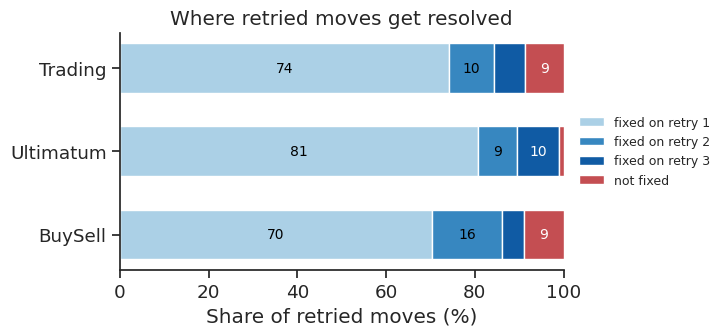

414 of 4265 moves (9.7%) needed a retry; 75% of those were fixed by the first retry; 28 exhausted the budget and lost the game (= the 28 incomplete retry3 games, almost all format/parse errors).


In [1006]:
#  Among retried moves, where did they get fixed? (retry3) 
retried = TURNS[(TURNS["retries"] > 0) | TURNS["failed"]].copy()
retried["outcome"] = np.where(retried["failed"], "not fixed",
                              retried["retries"].map(lambda k: f"fixed on retry {k}"))
order = ["fixed on retry 1", "fixed on retry 2", "fixed on retry 3", "not fixed"]
shares = (retried.groupby("game")["outcome"].value_counts(normalize=True)
          .unstack().reindex(columns=order).fillna(0).reindex(list(GAMES)) * 100)

blues = sns.color_palette("Blues", 5)
colors = [blues[1], blues[3], blues[4], "#c44e52"]
dark_text = {"fixed on retry 3", "not fixed"}
fig, ax = plt.subplots(figsize=(7.5, 3.6))
left = np.zeros(len(shares))
for col, color in zip(order, colors):
    vals = shares[col].values
    ax.barh(shares.index, vals, left=left, color=color, label=col, height=0.6)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=10,
                    color="white" if col in dark_text else "black")
    left += vals
ax.set_xlim(0, 100); ax.set_xlabel("Share of retried moves (%)")
ax.invert_yaxis()
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.set_title('Where retried moves get resolved')
fig.tight_layout(); plt.show()

n_retried, n_turns = len(retried), len(TURNS)
print(f"{n_retried} of {n_turns} moves ({n_retried / n_turns:.1%}) needed a retry; "
      f"{(retried['outcome'] == 'fixed on retry 1').mean():.0%} of those were fixed by the "
      f"first retry; {int(retried['failed'].sum())} exhausted the budget and lost the game "
      f"(= the {int((~RETRY3['completed']).sum())} incomplete retry3 games, almost all format/parse errors).")

**How much does self-correction actually rescue?** At the move level (retry3): of every move that triggered at least one retry, what share was eventually parsed within the 3-retry budget vs. exhausted it and lost the game. `needing_sc_%` is the share of *all* moves that needed a retry; `solve_rate_%` is the share of *those* that the budget resolved.

In [1007]:
#  Table: what self-correction resolves (move level, retry3) 
sc = TURNS[(TURNS["retries"] > 0) | TURNS["failed"]].copy()
sc["solved"] = ~sc["failed"]
sc["solved_1st"] = sc["solved"] & (sc["retries"] == 1)

def sc_table(by):
    g = sc.groupby(by)
    t = pd.DataFrame({
        "total_moves": TURNS.groupby(by).size(),
        "needing_sc": g.size(),
        "solved": g["solved"].sum().astype(int),
        "still_failed": g["failed"].sum().astype(int),
        "solve_rate_%": g["solved"].mean().mul(100),
        "solved_on_1st_%": g["solved_1st"].mean().mul(100),
    })
    t.insert(2, "needing_sc_%", t["needing_sc"] / t["total_moves"] * 100)
    return t

def overall():
    t = pd.DataFrame({
        "total_moves": [len(TURNS)], "needing_sc": [len(sc)],
        "needing_sc_%": [len(sc) / len(TURNS) * 100],
        "solved": [int(sc["solved"].sum())], "still_failed": [int(sc["failed"].sum())],
        "solve_rate_%": [sc["solved"].mean() * 100],
        "solved_on_1st_%": [sc["solved_1st"].mean() * 100],
    }, index=["All"])
    return t[["total_moves", "needing_sc", "needing_sc_%", "solved", "still_failed",
              "solve_rate_%", "solved_on_1st_%"]]

by_game = pd.concat([sc_table("game").reindex(list(GAMES)), overall()])
by_tier = sc_table("size").reindex(SIZES).rename(index=SIZE_LABELS)

print("Self-correction resolution by game (retry3, move level):")
display(by_game.round(1))
print("\nBy tier:")
display(by_tier.round(1))

Self-correction resolution by game (retry3, move level):


,total_moves,needing_sc,needing_sc_%,solved,still_failed,solve_rate_%,solved_on_1st_%
Trading,1552,209,13.5,191,18,91.4,74.2
Ultimatum,1152,104,9.0,103,1,99.0,80.8
BuySell,1561,101,6.5,92,9,91.1,70.3
All,4265,414,9.7,386,28,93.2,74.9



By tier:


,total_moves,needing_sc,needing_sc_%,solved,still_failed,solve_rate_%,solved_on_1st_%
size,,,,,,,
Very Small,1313,150,11.4,123,27,82.0,65.3
Small,1388,202,14.6,202,0,100.0,77.2
Medium,1564,62,4.0,61,1,98.4,90.3


<!-- INSIGHTS_COMPLETION -->
**Insights**

- **How often -> completion is an inverted-U in size, not monotonic.** Without retries the *small*
  tier (12-14B) is at ceiling (0.96-1.00), while *very_small* (0.72-0.95) and *medium* (0.68-0.94,
  worst: Trading 0.678) both drop below it. Scaling does not buy format robustness.
- **Why -> each game has a signature failure mode** (without retries). Trading dies to missing
  `<player answer>` tags (47) and unparseable resource amounts (26); BuySell to malformed trade
  lines missing the `|` separator (40); Ultimatum to a missing `<MOVE>` tag (18).
- **Who -> fragility is model-specific, not tier-wide.** Of 195 no-retry (retry0) failures,
  `gemma-3-4b-it` alone causes 69; the medium dip is driven by Qwen3.5-27B (45) and Mistral-Small
  (43), while `gemma-3-12b-it` never fails and `gemma-3-27b-it` only 4 times, so the dip is not a
  property of the *tier*.
- **Does it help -> three retries recover almost everything.** `retry3` completion is ≥ 0.99
  everywhere except very_small (Trading 0.906, BuySell 0.950). Retrying erases the tag-omission
  classes entirely (missing `<player answer>` 58→0, `<my resources>` 22→0, `<MOVE>` 18→0); only the
  invented-schema resource errors survive (unparseable 33→18).
- **How much ->** 9.7% of all moves are malformed, **75% of those are fixed
  by the first retry**, and only 28 / 1620 games still die. Qwen is the heaviest retry consumer (284 of 414 retried moves, in Trading and
  Ultimatum) yet the strongest negotiator (§2) and almost never fatal (1 of 28); Gemma retries less
  but fails hardest: **26 of the 28 budget-exhausting failures are `gemma-3-4b-it`**.
- **Consequence:** `retry3` removes the completion confound, so the outcome differences below
  reflect negotiation behaviour, not parsing problems.

### Does the retry loop change who wins?

The retry loop rescues games that would otherwise die on format errors (above) — but does it change
the *outcomes*? If the rescued games were negotiated differently from the games that complete on
their own, switching retries on would reshuffle who wins, and the rest of this chapter (which uses
`retry3`) would describe a different population than the `no_retries` baseline. As a robustness check
we compare the pooled family win rate under both conditions, before ranking the models in §2. Note
the `no_retries` sample is smaller and survivorship-biased (only format-robust games complete);
`pairwise_panel(game, condition="no_retries")` reproduces any later matrix under the baseline.

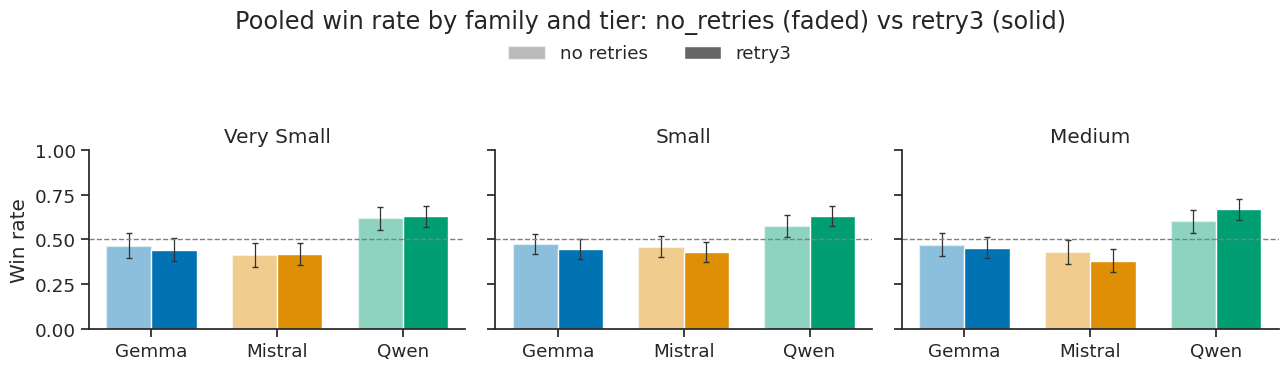

condition           no_retries  retry3
size       family                     
very_small Gemma         0.464   0.444
           Mistral       0.411   0.417
           Qwen          0.621   0.630
small      Gemma         0.475   0.449
           Mistral       0.459   0.430
           Qwen          0.576   0.634
medium     Gemma         0.471   0.453
           Mistral       0.427   0.380
           Qwen          0.601   0.668

Spearman rho between the two condition rankings (9 family x tier cells): 0.917


In [1008]:
#  A1: pooled win rate by family and tier, retry3 vs no_retries
MV_NR = model_view(MASTER[MASTER["condition"] == "no_retries"].copy())
rows = []
for cond, mv in [("no_retries", MV_NR), ("retry3", MV)]:
    d_ = mv[mv["win"].notna()]
    a = d_.groupby(["size", "family"]).agg(wins=("win", "sum"), n=("win", "count")).reset_index()
    a["win_rate"] = a["wins"] / a["n"]
    a[["lo", "hi"]] = a.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)
    rows.append(a.assign(condition=cond))
ab = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, size in zip(axes, SIZES):
    sub = ab[ab["size"] == size]
    x = np.arange(len(FAMILIES))
    for j, (cond, alpha) in enumerate([("no_retries", 0.45), ("retry3", 1.0)]):
        s = sub[sub["condition"] == cond].set_index("family").reindex(FAMILIES)
        pos = x + (j - 0.5) * 0.36
        ax.bar(pos, s["win_rate"], 0.36, color=[fam_pal[f] for f in FAMILIES], alpha=alpha)
        ax.errorbar(pos, s["win_rate"],
                    yerr=np.clip([s["win_rate"] - s["lo"], s["hi"] - s["win_rate"]], 0, None),
                    fmt="none", ecolor="0.2", capsize=2, lw=0.9)
    ax.axhline(0.5, ls="--", color="0.5", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(FAMILIES)
    ax.set_title(SIZE_LABELS[size])
axes[0].set_ylabel("Win rate"); axes[0].set_ylim(0, 1)
_h = [mpatches.Patch(facecolor="0.4", alpha=0.45, label="no retries"),
      mpatches.Patch(facecolor="0.4", label="retry3")]
fig.legend(handles=_h, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=2, frameon=False)
fig.suptitle("Pooled win rate by family and tier: no_retries (faded) vs retry3 (solid)")
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

pvt = (ab.pivot_table(index=["size", "family"], columns="condition", values="win_rate")
       .reindex(SIZES, level=0))
rho_c, _ = sps.spearmanr(pvt["retry3"], pvt["no_retries"])
print(pvt.round(3).to_string())
print(f"\nSpearman rho between the two condition rankings (9 family x tier cells): {rho_c:.3f}")

<!-- INSIGHTS_APPENDIX -->
**Verdict:** the ranking is robust to the retry condition. Qwen leads and Mistral trails in every
tier under both conditions (Spearman ρ = 0.917 across the 9 family × tier win rates) and no
family changes side of parity; the largest shift is Qwen at medium (0.601 → 0.668). The
`no_retries` condition measures format robustness, not different negotiation behaviour.


## 2. Who negotiates best? (retry3)

The remaining sections use the `retry3` condition; §1 showed it is the fair benchmark, with completion ≥ 0.99 nearly everywhere. Win rate is over games with a winner (ties are excluded); the dashed line marks parity (0.5) and error bars are 95% Wilson CIs. 

### Who wins?


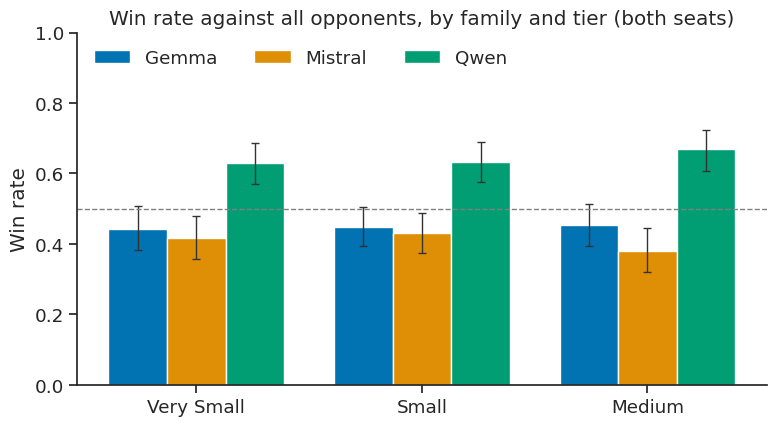

      size  family  wins   n  win_rate    lo    hi
    medium   Gemma 121.0 267     0.453 0.395 0.513
    medium Mistral  89.0 234     0.380 0.321 0.444
    medium    Qwen 161.0 241     0.668 0.606 0.724
     small   Gemma 135.0 301     0.449 0.393 0.505
     small Mistral 129.0 300     0.430 0.375 0.487
     small    Qwen 173.0 273     0.634 0.575 0.689
very_small   Gemma 106.0 239     0.444 0.382 0.507
very_small Mistral 105.0 252     0.417 0.357 0.478
very_small    Qwen 167.0 265     0.630 0.571 0.686


In [1009]:
#  P1: pooled win rate vs all opponents, by family and tier 
dec = MV[MV["win"].notna()]
pal = dict(zip(FAMILIES, sns.color_palette("colorblind", 3)))
agg = (dec.groupby(["size", "family"])
       .agg(wins=("win", "sum"), n=("win", "count")).reset_index())
agg["win_rate"] = agg["wins"] / agg["n"]
agg[["lo", "hi"]] = agg.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(SIZES)); width = 0.26
for i, fam in enumerate(FAMILIES):
    sub = agg[agg["family"] == fam].set_index("size").reindex(SIZES)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["win_rate"], width, label=fam, color=pal[fam])
    ax.errorbar(pos, sub["win_rate"],
                yerr=[sub["win_rate"] - sub["lo"], sub["hi"] - sub["win_rate"]],
                fmt="none", ecolor="0.2", capsize=3, lw=1)
ax.axhline(0.5, ls="--", color="0.5", lw=1)
ax.set_xticks(x); ax.set_xticklabels([SIZE_LABELS[s] for s in SIZES])
ax.set_ylabel("Win rate"); ax.set_ylim(0, 1)
ax.legend(loc="upper left", ncols=3)
ax.set_title('Win rate against all opponents, by family and tier (both seats)')
fig.tight_layout(); plt.show()

print(agg.assign(win_rate=agg.win_rate.round(3), lo=agg.lo.round(3), hi=agg.hi.round(3))
      .to_string(index=False))

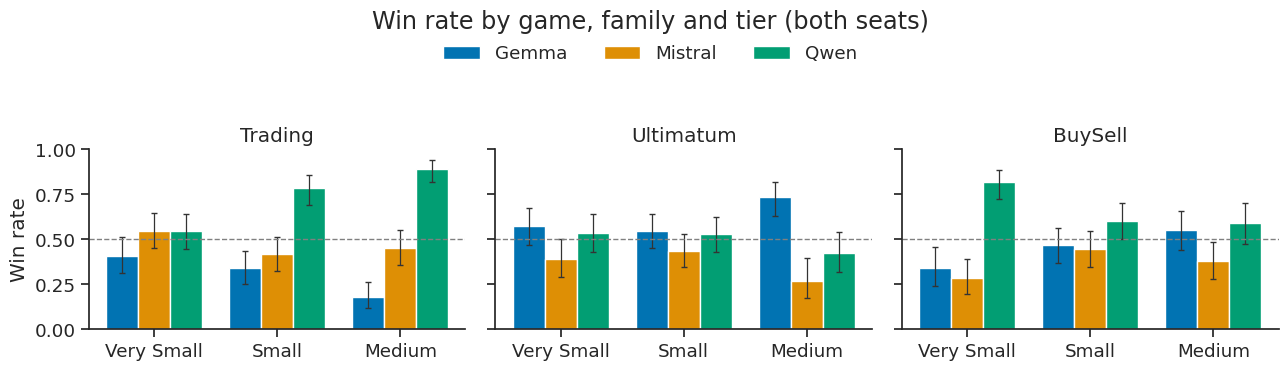

size               very_small  small  medium
game      family                            
BuySell   Gemma         0.338  0.464   0.550
          Mistral       0.280  0.442   0.375
          Qwen          0.816  0.602   0.588
Trading   Gemma         0.404  0.337   0.176
          Mistral       0.546  0.414   0.449
          Qwen          0.543  0.784   0.892
Ultimatum Gemma         0.573  0.544   0.734
          Mistral       0.388  0.434   0.268
          Qwen          0.535  0.526   0.423


In [1010]:
#  P2: win rate per game, family and tier
aggg = (dec.groupby(["game", "size", "family"])
        .agg(wins=("win", "sum"), n=("win", "count")).reset_index())
aggg["win_rate"] = aggg["wins"] / aggg["n"]
aggg[["lo", "hi"]] = aggg.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, game in zip(axes, GAMES):
    gsub = aggg[aggg["game"] == game]
    for i, fam in enumerate(FAMILIES):
        sub = gsub[gsub["family"] == fam].set_index("size").reindex(SIZES)
        pos = np.arange(len(SIZES)) + (i - 1) * 0.26
        ax.bar(pos, sub["win_rate"], 0.26, label=fam, color=pal[fam])
        ax.errorbar(pos, sub["win_rate"],
                    yerr=[sub["win_rate"] - sub["lo"], sub["hi"] - sub["win_rate"]],
                    fmt="none", ecolor="0.2", capsize=2, lw=0.9)
    ax.axhline(0.5, ls="--", color="0.5", lw=1)
    ax.set_xticks(np.arange(len(SIZES)))
    ax.set_xticklabels([SIZE_LABELS[s] for s in SIZES])
    ax.set_title(game)
axes[0].set_ylabel("Win rate"); axes[0].set_ylim(0, 1)
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=3, frameon=False)
fig.suptitle("Win rate by game, family and tier (both seats)")
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

print(aggg.pivot_table(index=["game", "family"], columns="size", values="win_rate")
      .reindex(columns=SIZES).round(3).to_string())

### Does winning pay?

Win rate ignores *margins*. Payoffs are not comparable across games in native units (Trading resource delta, Ultimatum dollars, BuySell profit), so for pooled views each game's payoff is min-max scaled to its feasible range (`PAYOFF_BOUNDS`: Trading ±30 units, Ultimatum 0–100 dollars, BuySell −40–60 surplus, since the price is bounded by the buyer's 100 ZUP); on that scale **0.5 is the symmetric outcome in every game**: no net trade, an equal split of the pot, an equal split of the 20-ZUP surplus (price 50). No-deals enter at their true payoff of 0: the symmetric point in Trading (0.5), slightly below it in BuySell (0.4, the missed surplus), and the *floor* in Ultimatum, where walking away destroys the pot. Means are over completed, payoff-valid games; error bars are 95% normal CIs.

If win rate and mean payoff told the same story, one metric would suffice. The scatter below checks where they agree, one game per panel and one point per (family, tier).


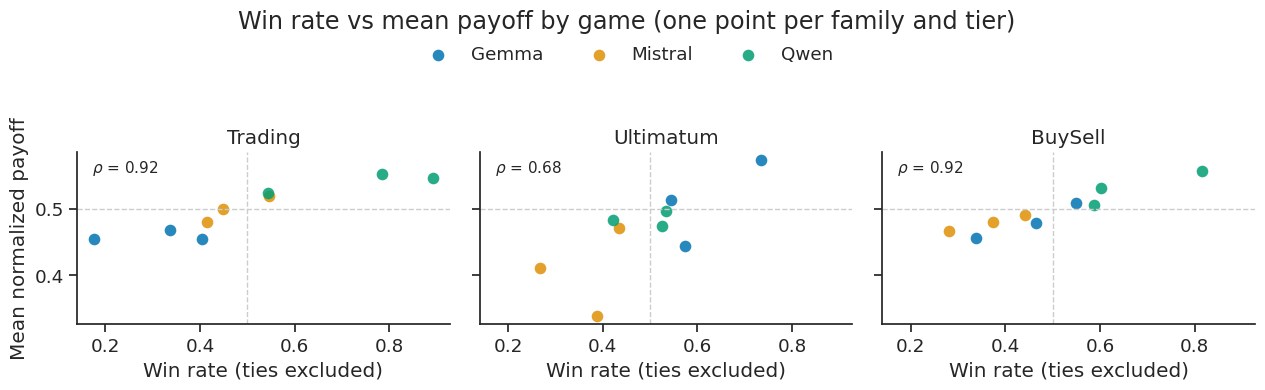

Overall Spearman rho = 0.808 (p = 3.5e-07, n = 27 family x game x tier cells)
  Trading: rho = 0.92 (n = 9)
  Ultimatum: rho = 0.68 (n = 9)
  BuySell: rho = 0.92 (n = 9)


In [1011]:
#  P3: win rate vs normalized payoff, by game (one point per family x tier)
pv = MV[MV["completed"] & MV["payoff_valid"]].copy()
_plo = pv["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_phi = pv["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
pv["payoff_norm"] = (pv["payoff"] - _plo) / (_phi - _plo)

wp = (dec.groupby(["game", "size", "family"])["win"].mean().rename("win_rate").reset_index()
      .merge(pv.groupby(["game", "size", "family"])["payoff_norm"].mean().reset_index()))
rho, pval = sps.spearmanr(wp["win_rate"], wp["payoff_norm"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, game in zip(axes, GAMES):
    gsub = wp[wp["game"] == game]
    for fam in FAMILIES:
        sub = gsub[gsub["family"] == fam]
        ax.scatter(sub["win_rate"], sub["payoff_norm"], s=70, color=pal[fam],
                   alpha=0.85, lw=0, label=fam)
    ax.axhline(0.5, ls="--", color="0.8", lw=1); ax.axvline(0.5, ls="--", color="0.8", lw=1)
    r_g, _ = sps.spearmanr(gsub["win_rate"], gsub["payoff_norm"])
    ax.text(0.04, 0.96, f"$\\rho$ = {r_g:.2f}", transform=ax.transAxes, va="top", fontsize=11)
    ax.set_title(game)
    ax.set_xlabel("Win rate (ties excluded)")
axes[0].set_ylabel("Mean normalized payoff")
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=3, frameon=False)
fig.suptitle("Win rate vs mean payoff by game (one point per family and tier)")
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

print(f"Overall Spearman rho = {rho:.3f} (p = {pval:.1e}, n = {len(wp)} family x game x tier cells)")
for game in GAMES:
    gsub = wp[wp["game"] == game]
    r_g, p_g = sps.spearmanr(gsub["win_rate"], gsub["payoff_norm"])
    print(f"  {game}: rho = {r_g:.2f} (n = {len(gsub)})")

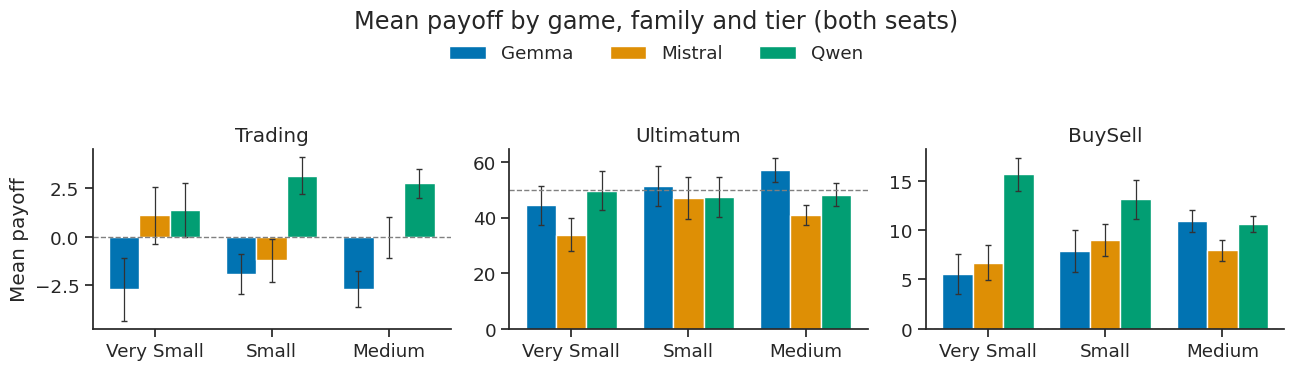

size               very_small  small  medium
game      family                            
BuySell   Gemma          5.57   7.87   10.92
          Mistral        6.70   9.02    7.98
          Qwen          15.64  13.12   10.60
Trading   Gemma         -2.72  -1.92   -2.71
          Mistral        1.10  -1.23   -0.05
          Qwen           1.40   3.15    2.76
Ultimatum Gemma         44.40  51.31   57.31
          Mistral       33.85  47.07   41.05
          Qwen          49.72  47.44   48.31


In [1012]:
#  P4: mean payoff per game (native units), by family and tier 
def _sem(s):
    s = s.dropna()
    return s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0

gp = (pv.groupby(["game", "size", "family"])
      .agg(mean=("payoff", "mean"), sem=("payoff", _sem)).reset_index())
gp["lo"] = gp["mean"] - 1.96 * gp["sem"]
gp["hi"] = gp["mean"] + 1.96 * gp["sem"]

NEUTRAL = {"Trading": 0, "Ultimatum": 50, "BuySell": 0}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, game in zip(axes, GAMES):
    gsub = gp[gp["game"] == game]
    for i, fam in enumerate(FAMILIES):
        sub = gsub[gsub["family"] == fam].set_index("size").reindex(SIZES)
        pos = np.arange(len(SIZES)) + (i - 1) * 0.26
        ax.bar(pos, sub["mean"], 0.26, label=fam, color=pal[fam])
        ax.errorbar(pos, sub["mean"],
                    yerr=[sub["mean"] - sub["lo"], sub["hi"] - sub["mean"]],
                    fmt="none", ecolor="0.2", capsize=2, lw=0.9)
    ax.axhline(NEUTRAL[game], ls="--", color="0.5", lw=1)
    ax.set_xticks(np.arange(len(SIZES)))
    ax.set_xticklabels([SIZE_LABELS[s] for s in SIZES])
    ax.set_title(game)
axes[0].set_ylabel("Mean payoff")
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=3, frameon=False)
fig.suptitle('Mean payoff by game, family and tier (both seats)')
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

print(gp.pivot_table(index=["game", "family"], columns="size", values="mean")
      .reindex(columns=SIZES).round(2).to_string())

In [1013]:
#  T1: master summary table (retry3)
cm = MV[MV["completed"]]
summary = (cm.groupby(["size", "family", "model"])
           .agg(games=("win", "size"),
                win_rate=("win", "mean"),                 # mean ignores NaN ties
                decided=("win", "count"),
                tie_share=("win", lambda s: s.isna().mean()),
                deal_rate=("deal", "mean"),
                turns=("num_turns", "mean")).reset_index())
claim = (pv[pv["deal"]].groupby(["size", "family", "model"])["payoff_norm"]
         .mean().rename("claim_given_deal").reset_index())
pay = (cm[cm["payoff_valid"]].pivot_table(index=["size", "family", "model"],
       columns="game", values="payoff", aggfunc="mean")
       .rename(columns=lambda c: f"payoff_{c}"))
summary = (summary.merge(claim, on=["size", "family", "model"])
           .merge(pay, on=["size", "family", "model"]))
summary["size"] = pd.Categorical(summary["size"], SIZES, ordered=True)
summary = summary.sort_values(["size", "family"]).round(3)
display(summary.set_index(["size", "family", "model"]))


games  win_rate  decided  \
size       family  model                                                  
very_small Gemma   gemma-3-4b-it                 333     0.444      239   
           Mistral Ministral-3-8B-2512           341     0.417      252   
           Qwen    Qwen3.5-9B                    352     0.630      265   
small      Gemma   gemma-3-12b-it                360     0.449      301   
           Mistral Ministral-3-14B-2512          360     0.430      300   
           Qwen    Qwen3-14B                     360     0.634      273   
medium     Gemma   gemma-3-27b-it                359     0.453      267   
           Mistral Mistral-Small-3.2-24B-2506    360     0.380      234   
           Qwen    Qwen3.5-27B                   359     0.668      241   

                                               tie_share  deal_rate  turns  \
size       family  model                                                     
very_small Gemma   gemma-3-4b-it                   0.282      0.907  2.273   
           Mistral Ministral-3-8B-2512             0.261      0.921  2.683   
           Qwen    Qwen3.5-9B                      0.247      0.955  2.534   
small      Gemma   gemma-3-12b-it                  0.164      0.986  2.606   
           Mistral Ministral-3-14B-2512            0.167      1.000  2.628   
           Qwen    Qwen3-14B                       0.242      0.986  2.478   
medium     Gemma   gemma-3-27b-it                  0.256      0.981  3.072   
           Mistral Mistral-Small-3.2-24B-2506      0.350      0.981  2.847   
           Qwen    Qwen3.5-27B                     0.329      1.000  2.758   

                                               claim_given_deal  \
size       family  model                                          
very_small Gemma   gemma-3-4b-it                          0.485   
           Mistral Ministral-3-8B-2512                    0.464   
           Qwen    Qwen3.5-9B                             0.547   
small      Gemma   gemma-3-12b-it                         0.493   
           Mistral Ministral-3-14B-2512                   0.480   
           Qwen    Qwen3-14B                              0.527   
medium     Gemma   gemma-3-27b-it                         0.519   
           Mistral Mistral-Small-3.2-24B-2506             0.469   
           Qwen    Qwen3.5-27B                            0.512   

                                               payoff_BuySell  payoff_Trading  \
size       family  model                                                        
very_small Gemma   gemma-3-4b-it                        5.568          -2.718   
           Mistral Ministral-3-8B-2512                  6.699           1.101   
           Qwen    Qwen3.5-9B                          15.636           1.404   
small      Gemma   gemma-3-12b-it                       7.867          -1.925   
           Mistral Ministral-3-14B-2512                 9.017          -1.225   
           Qwen    Qwen3-14B                           13.117           3.150   
medium     Gemma   gemma-3-27b-it                      10.925          -2.706   
           Mistral Mistral-Small-3.2-24B-2506           7.975          -0.050   
           Qwen    Qwen3.5-27B                         10.600           2.756   

                                               payoff_Ultimatum  
size       family  model                                         
very_small Gemma   gemma-3-4b-it                         44.398  
           Mistral Ministral-3-8B-2512                   33.847  
           Qwen    Qwen3.5-9B                            49.725  
small      Gemma   gemma-3-12b-it                        51.311  
           Mistral Ministral-3-14B-2512                  47.067  
           Qwen    Qwen3-14B                             47.442  
medium     Gemma   gemma-3-27b-it                        57.308  
           Mistral Mistral-Small-3.2-24B-2506            41.050  
           Qwen    Qwen3.5-27B                           48.308

### Table 4.2 - cross-play summary per family and tier

Win rate over all games and opponents (ties excluded, 95% Wilson CI) and mean payoff per game
(95% percentile-bootstrap CI). Payoffs are game-specific (Trading: net resource change; Ultimatum:
dollars kept; BuySell: surplus) and are **not** comparable across columns. `retry3` condition;
payoff means use completed, payoff-valid games only.

In [1014]:
#  Table 4.2: cross-play summary per family x tier -- pooled win rate (ties excluded, Wilson 95% CI)
#  and mean payoff per game (95% percentile-bootstrap CI). retry3; payoff-valid completed games.
def _boot_mean_ci(x, n_boot=10000, seed=0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(means, [2.5, 97.5])
    return x.mean(), lo, hi

_dec = MV[MV["win"].notna()]
_pv = MV[MV["completed"] & MV["payoff_valid"]]

_t42 = []
for _sz in SIZES:
    for _fam in FAMILIES:
        _d = _dec[(_dec["size"] == _sz) & (_dec["family"] == _fam)]
        _w, _n = int(_d["win"].sum()), len(_d)
        _wlo, _whi = wilson_ci(_w, _n)
        _row = {
            "Tier": TIER_LABEL[_sz],
            "Family": _fam,
            "Win rate": f"{_w / _n:.2f} [{_wlo:.2f},{_whi:.2f}]" if _n else "-",
        }
        for _game in GAMES:
            _p = _pv[(_pv["size"] == _sz) & (_pv["family"] == _fam)
                     & (_pv["game"] == _game)]["payoff"].values
            _m, _lo, _hi = _boot_mean_ci(_p)
            _row[_game] = f"{_m:.1f} [{_lo:.1f},{_hi:.1f}]"
        _t42.append(_row)

TABLE_42 = pd.DataFrame(_t42).set_index(["Tier", "Family"])

try:
    display(TABLE_42)
except NameError:
    pass
print("Table 4.2 - Cross-play summary per family and tier")
#print(TABLE_42.to_string())

Win rate           Trading         Ultimatum  \
Tier   Family                                                          
4-9B   Gemma    0.44 [0.38,0.51]  -2.7 [-4.3,-1.1]  44.4 [37.5,51.1]   
       Mistral  0.42 [0.36,0.48]    1.1 [-0.4,2.6]  33.8 [28.0,39.7]   
       Qwen     0.63 [0.57,0.69]     1.4 [0.0,2.8]  49.7 [42.8,56.8]   
12-14B Gemma    0.45 [0.39,0.50]  -1.9 [-3.0,-0.9]  51.3 [44.0,58.5]   
       Mistral  0.43 [0.38,0.49]  -1.2 [-2.4,-0.1]  47.1 [39.6,54.6]   
       Qwen     0.63 [0.58,0.69]     3.1 [2.2,4.1]  47.4 [40.3,54.5]   
24-27B Gemma    0.45 [0.39,0.51]  -2.7 [-3.6,-1.8]  57.3 [52.9,61.5]   
       Mistral  0.38 [0.32,0.44]   -0.1 [-1.1,1.0]  41.0 [37.6,44.6]   
       Qwen     0.67 [0.61,0.72]     2.8 [2.0,3.5]  48.3 [44.3,52.4]   

                         BuySell  
Tier   Family                     
4-9B   Gemma       5.6 [3.5,7.5]  
       Mistral     6.7 [5.0,8.5]  
       Qwen     15.6 [14.0,17.4]  
12-14B Gemma      7.9 [5.7,10.0]  
       Mistral    9.0 [7.4,10.7]  
       Qwen     13.1 [11.1,15.1]  
24-27B Gemma     10.9 [9.8,12.0]  
       Mistral     8.0 [6.9,9.0]  
       Qwen      10.6 [9.8,11.4]

Table 4.2 - Cross-play summary per family and tier


<!-- INSIGHTS_HEADLINE -->
**Insights**

- **The family ranking is stable across all three tiers.** Pooled over games, Qwen tops every
  tier (0.630 / 0.634 / 0.668, Wilson CIs entirely above parity), Gemma sits just below parity
  (0.444–0.453) and Mistral is last (0.380–0.430). Scaling from 4B to 27B never reorders the
  families; training/style differences dominate parameter count in this range.
- **But the per-game evidence is thinner than the bars suggest.** Qwen's clear edges are Trading at
  small/medium (0.784 / 0.892) and BuySell at very_small (0.816); Ultimatum is Gemma's game
  (0.734 at medium, its only clear advantage).
- **Payoff mostly agrees with WinRate (Ultimatum is an exception).** (ρ = 0.92 Trading, 0.68
  Ultimatum, 0.92 BuySell); 


## 3. Role & order effects

### Does the seat matter more than the model?

NegotiationArena found that *turn and role matter* (§3.2 of the paper): the proposer dominates multi-turn Ultimatum while the second mover tends to win Resource Exchange. Both orderings of every pair exist here (30 games each), so seat effects are measurable directly, setting the lens for reading the pairwise matrices in §4.


In [1015]:
#  P4: first-mover win rate per game (ties excluded) 
decg = RETRY3[RETRY3["winner"].isin(["P1", "P2"])]
rows = []
for (game, size), sub in decg.groupby(["game", "size"]):
    k = (sub["winner"] == "P1").sum(); n = len(sub)
    lo, hi = wilson_ci(k, n)
    rows.append({"game": game, "size": size, "p1_win": k / n, "lo": lo, "hi": hi, "n": n})
seat = pd.DataFrame(rows)

spal = dict(zip(SIZES, sns.color_palette("crest", 3)))
print(seat.round(3).to_string(index=False))


     game       size  p1_win    lo    hi   n
  BuySell     medium   0.325 0.246 0.415 114
  BuySell      small   0.121 0.077 0.186 140
  BuySell very_small   0.270 0.197 0.357 115
  Trading     medium   0.286 0.220 0.362 154
  Trading      small   0.215 0.156 0.289 144
  Trading very_small   0.252 0.187 0.330 139
Ultimatum     medium   0.903 0.830 0.946 103
Ultimatum      small   0.967 0.926 0.986 153
Ultimatum very_small   0.855 0.782 0.906 124


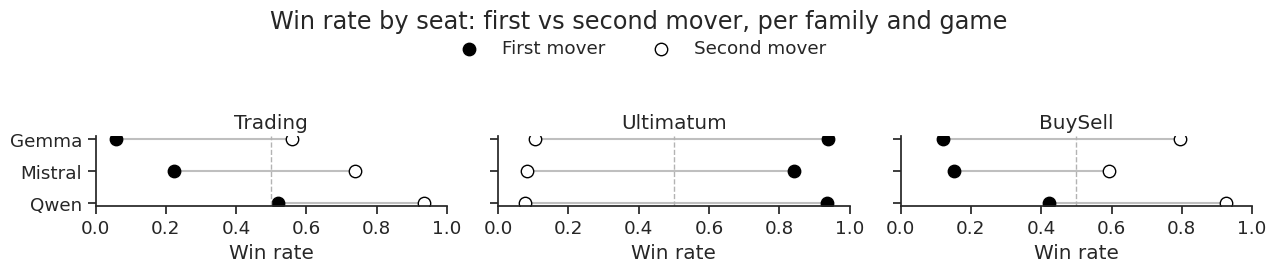

seat                  P1     P2
game      family               
BuySell   Gemma    0.122  0.795
          Mistral  0.152  0.592
          Qwen     0.421  0.926
Trading   Gemma    0.058  0.559
          Mistral  0.222  0.738
          Qwen     0.519  0.935
Ultimatum Gemma    0.938  0.106
          Mistral  0.842  0.082
          Qwen     0.936  0.078


In [1016]:
#  Order effect per family: win rate when moving first vs second 
fam_seat = (dec.groupby(["game", "family", "seat"])["win"].agg(["mean", "count"])
            .reset_index().rename(columns={"mean": "win_rate", "count": "n"}))
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8), sharex=True, sharey=True)
for ax, game in zip(axes, GAMES):
    sub = fam_seat[fam_seat["game"] == game]
    for j, fam in enumerate(FAMILIES):
        fsub = sub[sub["family"] == fam].set_index("seat")
        w1, w2 = fsub.loc["P1", "win_rate"], fsub.loc["P2", "win_rate"]
        ax.plot([w1, w2], [j, j], color="0.75", lw=1.5, zorder=1)
        ax.scatter([w1], [j], s=80, facecolor="black", edgecolor="black", zorder=2,
                   label="First mover" if j == 0 else None)
        ax.scatter([w2], [j], s=80, facecolor="white", edgecolor="black", zorder=2,
                   label="Second mover" if j == 0 else None)
    ax.axvline(0.5, ls="--", color="0.7", lw=1)
    ax.set_yticks(range(len(FAMILIES))); ax.set_yticklabels(FAMILIES)
    ax.set_xlim(0, 1); ax.set_title(game); ax.set_xlabel("Win rate")
axes[0].invert_yaxis()
_h, _l = axes[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=2, frameon=False)
fig.suptitle('Win rate by seat: first vs second mover, per family and game')
fig.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

print(fam_seat.pivot_table(index=["game", "family"], columns="seat", values="win_rate")
      .round(3).to_string())

<!-- INSIGHTS_SEATS -->
**Insights**

- **The paper's "turn and role matter" finding replicates on open-weight models, with the same
  signs.** The Ultimatum proposer wins 0.86–0.97 of the games with a winner, while in Trading and BuySell
  the *second* mover wins most (P1 win rate only 0.12–0.33). The BuySell case is the paper's buyer
  advantage: the buyer moves second and 55% of deals close below the midpoint (§5).


## 4. Game by game (retry3)

The pooled views in §2 average over three structurally different games. This section takes them one at a time: who beats whom (full ordered-pair matrices: **rows = the model as Player 1, columns = as Player 2**, so every pair appears twice, once per seat (read §3's seat effects into every cell); top row = row player's win rate over games with a winner, bottom row = row player's mean payoff over completed payoff-valid games, color scale shared across tiers; the win/loss counts behind each cell are printed below each figure; diagonals are empty as the benchmark has no self-play) and what the moves inside each game look like.


In [1017]:
#  Pairwise matrices from MASTER: rows = model as P1, columns = model as P2
def pairwise_panel(game, condition="retry3"):
    g = MASTER[(MASTER["game"] == game) & (MASTER["condition"] == condition)]
    data = {}
    for size in SIZES:
        sub = g[g["size"] == size]
        models = sorted(set(sub["model_1"]) | set(sub["model_2"]))
        d = sub[sub["winner"].isin(["P1", "P2"])]
        k = (d.assign(w=(d["winner"] == "P1").astype(int))
             .pivot_table(index="model_1", columns="model_2", values="w", aggfunc="sum")
             .reindex(index=models, columns=models))
        n = (d.pivot_table(index="model_1", columns="model_2", values="winner", aggfunc="size")
             .reindex(index=models, columns=models))
        pay = (sub[sub["completed"] & sub["payoff_valid"]]
               .pivot_table(index="model_1", columns="model_2", values="payoff_1")
               .reindex(index=models, columns=models))
        data[size] = (k, n, pay)
    pmin = min(p.min().min() for _, _, p in data.values())
    pmax = max(p.max().max() for _, _, p in data.values())

    fig, axes = plt.subplots(2, 3, figsize=(14, 8.2))
    for ci, size in enumerate(SIZES):
        k, n, pay = data[size]
        sns.heatmap(k / n, annot=True, fmt=".2f", cmap=colormap, vmin=0, vmax=1,
                    cbar=False, ax=axes[0, ci])
        sns.heatmap(pay, annot=True, fmt=".1f", cmap=colormap, vmin=pmin, vmax=pmax,
                    cbar=False, ax=axes[1, ci])
        axes[0, ci].set_title(SIZE_LABELS[size])
        for ri in (0, 1):
            ax = axes[ri, ci]
            ax.set_xlabel("as Player 2" if ri == 1 else "")
            ax.set_ylabel("")
            ax.set_xticklabels(ax.get_xticklabels() if ri == 1 else [],
                               rotation=30, ha="right", fontsize=9)
            ax.set_yticklabels(ax.get_yticklabels() if ci == 0 else [], rotation=0, fontsize=9)
    axes[0, 0].set_ylabel("Win rate\nas Player 1")
    axes[1, 0].set_ylabel("Mean payoff\nas Player 1")
    fig.suptitle(f"{game}  -  row player (P1) win rate and mean payoff vs column player (P2), {condition}")
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

    for size, (k, n, _) in data.items():
        kn = pd.DataFrame(index=k.index, columns=k.columns, dtype=object)
        for r_ in k.index:
            for c_ in k.columns:
                nn = n.loc[r_, c_]
                kk = 0 if pd.isna(k.loc[r_, c_]) else k.loc[r_, c_]
                kn.loc[r_, c_] = "-" if pd.isna(nn) else f"{int(kk)}/{int(nn)}"
        print(f"{game} {SIZE_LABELS[size]}  -  wins k/n, ties excluded (row = P1):")
        print(kn.to_string(), "\n")


### Trading

Each side starts with 25 units of one resource and 5 of the other and trades freely for up to 8 rounds. With both resources valued at one unit apiece, resources are conserved: every deal is exactly zero-sum (§2.4), so Trading measures pure *claiming*. The paper found the second mover tends to win; §3 confirms it here (the first mover wins only 0.22–0.29 of the games with a winner).


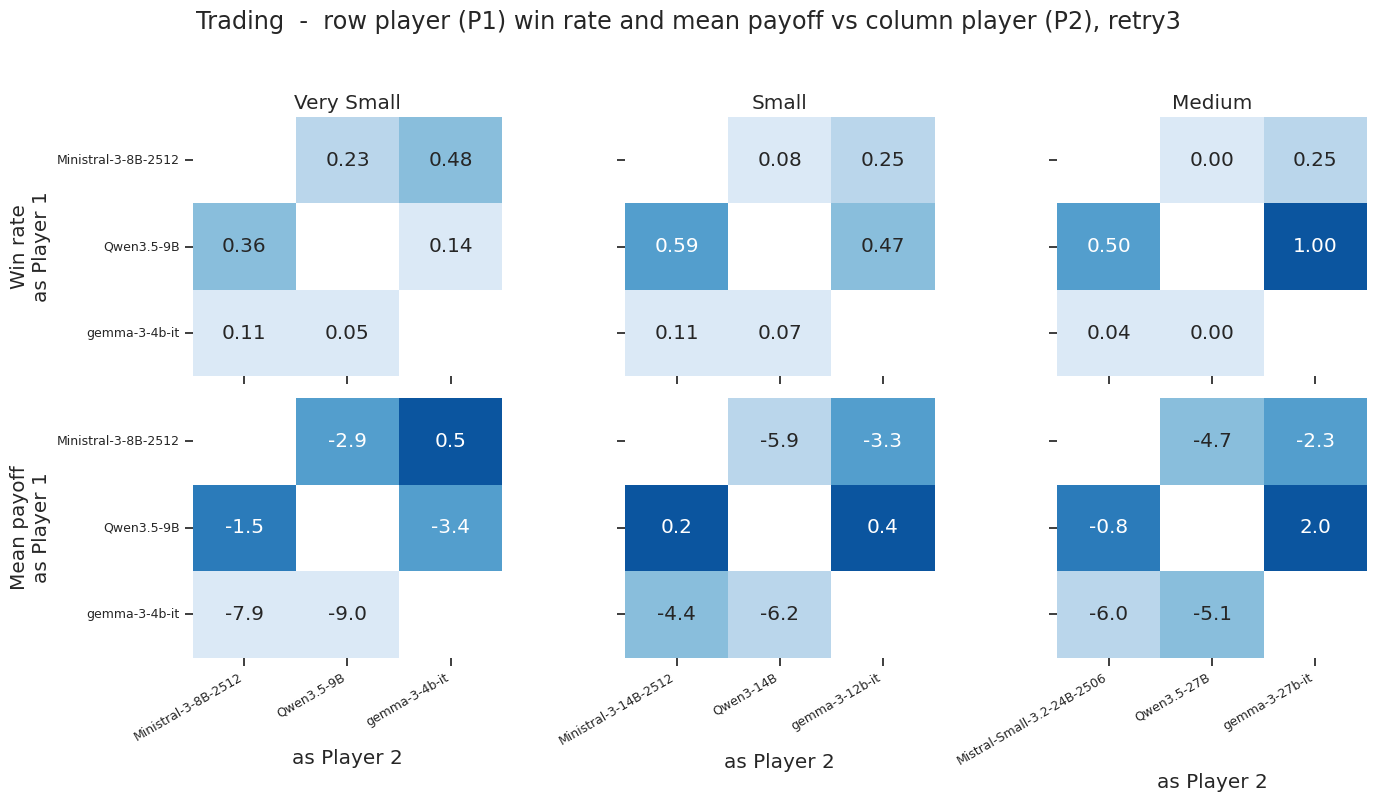

Trading Very Small  -  wins k/n, ties excluded (row = P1):
model_2             Ministral-3-8B-2512 Qwen3.5-9B gemma-3-4b-it
model_1                                                         
Ministral-3-8B-2512                   -       5/22         14/29
Qwen3.5-9B                        10/28          -          3/21
gemma-3-4b-it                      2/18       1/21             - 

Trading Small  -  wins k/n, ties excluded (row = P1):
model_2              Ministral-3-14B-2512 Qwen3-14B gemma-3-12b-it
model_1                                                           
Ministral-3-14B-2512                    -      2/26           7/28
Qwen3-14B                           10/17         -           7/15
gemma-3-12b-it                       3/28      2/30              - 

Trading Medium  -  wins k/n, ties excluded (row = P1):
model_2                    Mistral-Small-3.2-24B-2506 Qwen3.5-27B gemma-3-27b-it
model_1                                                                         
Mistra

In [1018]:
pairwise_panel("Trading")

<!-- INSIGHTS_TRADING -->
**Insights**

- **Trading is where the family gap widens with scale**, the only game with a clear scaling
  direction, and it is divergence, not improvement: Qwen climbs 0.543 → 0.784 → 0.892 while
  Gemma slides 0.404 → 0.337 → 0.176; from the small tier up all four CIs are clear of parity.
- **Medium Qwen3.5-27B dominates from both seats**: 26/26 as Player 1 against gemma-3-27b-it and
  a perfect 30/30 + 24/24 as Player 2; the only games it drops are to Mistral-Small when Qwen
  holds the disadvantaged first-mover seat (11/22). No other model dominates a game from both
  seats.


### Ultimatum

The proposer holds the $100 pot; the responder can accept, counter-propose, or reject and destroy the pot. §3 showed the seat dominates everything else in this game (the proposer wins 0.86–0.97 of the games with a winner), so the interesting variation is *within* the deals: how much do proposers take, and do responders ever push back?


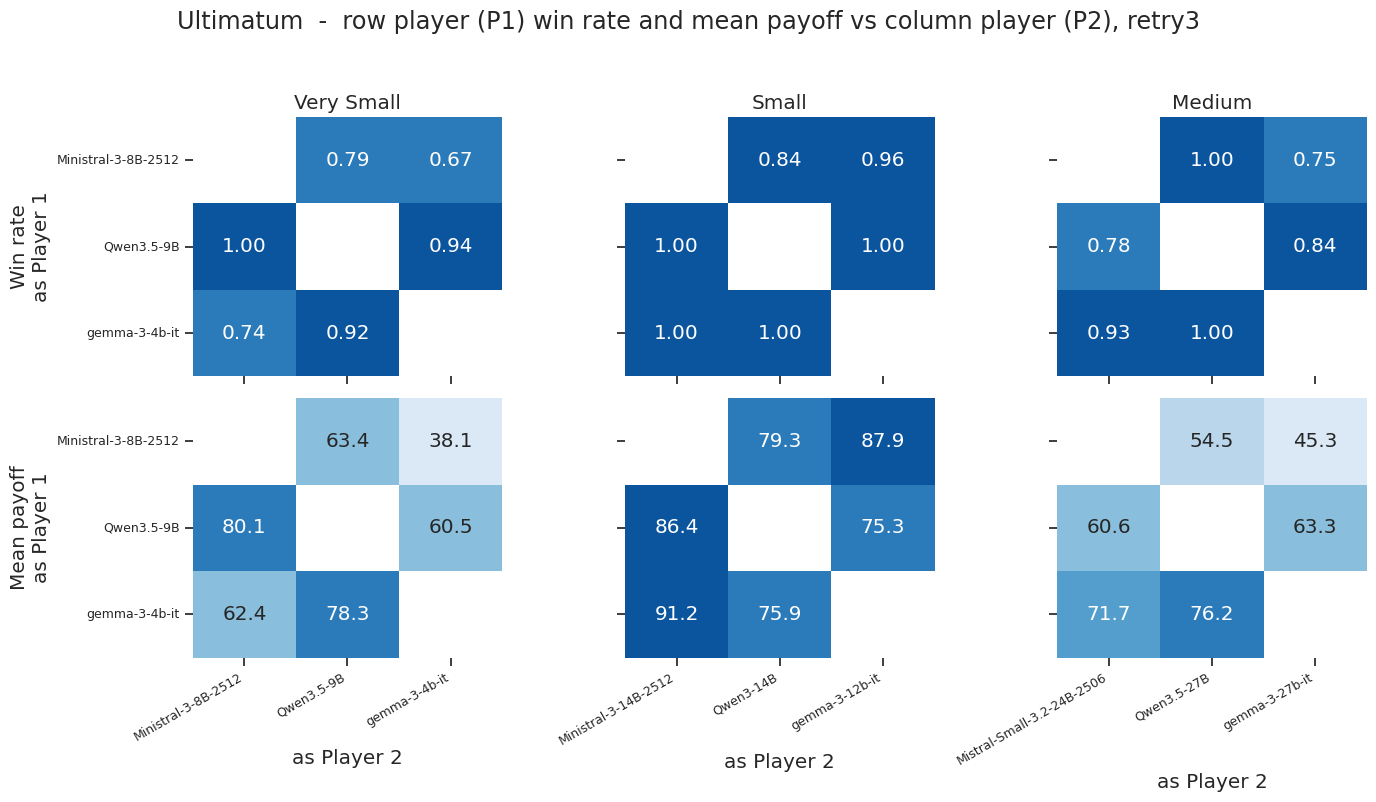

Ultimatum Very Small  -  wins k/n, ties excluded (row = P1):
model_2             Ministral-3-8B-2512 Qwen3.5-9B gemma-3-4b-it
model_1                                                         
Ministral-3-8B-2512                   -      15/19         10/15
Qwen3.5-9B                        23/23          -         17/18
gemma-3-4b-it                     17/23      24/26             - 

Ultimatum Small  -  wins k/n, ties excluded (row = P1):
model_2              Ministral-3-14B-2512 Qwen3-14B gemma-3-12b-it
model_1                                                           
Ministral-3-14B-2512                    -     21/25          25/26
Qwen3-14B                           25/25         -          22/22
gemma-3-12b-it                      30/30     25/25              - 

Ultimatum Medium  -  wins k/n, ties excluded (row = P1):
model_2                    Mistral-Small-3.2-24B-2506 Qwen3.5-27B gemma-3-27b-it
model_1                                                                         


In [1019]:
pairwise_panel("Ultimatum")

#### Do proposers anchor the split?

NegotiationArena found that stronger models open the Ultimatum with **lower** offers to the
responder (Claude opened ~10\$ below GPT), keeping more of the pot for themselves. We compare the
opening offer P1 makes to the responder across families and tiers; the dashed line at 50 marks an
even split, and a lower bar means a more aggressive proposer.

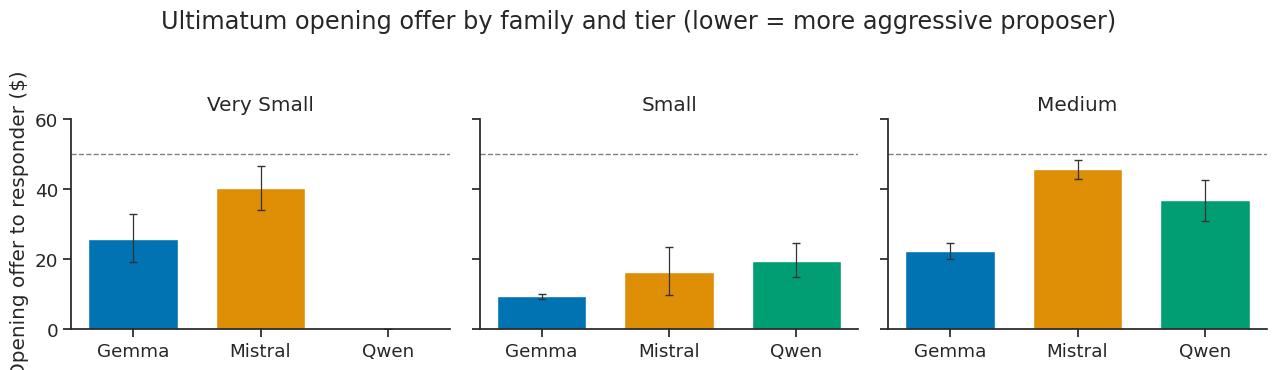

open_offer  p1_payoff   n
tier       family                            
very_small Gemma          25.5       72.2  49
           Mistral        40.2       52.6  60
           Qwen            0.0      100.0   1
small      Gemma           9.3       85.6  53
           Mistral        16.1       85.5  60
           Qwen           19.5       80.5  59
medium     Gemma          22.1       73.9  60
           Mistral        45.8       50.8  59
           Qwen           36.6       62.0  60

open_offer = mean $ offered to the responder on turn 1; p1_payoff = mean $ the proposer keeps (0 when the split is rejected).


In [1020]:
#  U1: Ultimatum opening offer (dollars P1 offers the responder), by family x tier
ult = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["completed"]].copy()
ult = ult[ult["ult_open_offer"].between(0, 100)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, sz in zip(axes, SIZES):
    sub = ult[ult["size"] == sz]
    for j, fam in enumerate(FAMILIES):
        m, lo, hi = _boot_mean_ci(sub[sub["family_1"] == fam]["ult_open_offer"].values)
        ax.bar(j, m, 0.7, color=pal[fam])
        ax.errorbar(j, m, yerr=[[max(m - lo, 0)], [max(hi - m, 0)]],
                    fmt="none", ecolor="0.2", capsize=3, lw=0.9)
    ax.axhline(50, ls="--", color="0.5", lw=1)
    ax.set_xticks(range(len(FAMILIES))); ax.set_xticklabels(FAMILIES)
    ax.set_title(SIZE_LABELS[sz])
axes[0].set_ylabel("Opening offer to responder ($)"); axes[0].set_ylim(0, 60)
fig.suptitle("Ultimatum opening offer by family and tier (lower = more aggressive proposer)")
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

#  companion: does opening lower mean keeping more? (payoff_1 = dollars the proposer keeps)
tbl = (ult.groupby(["size", "family_1"])
       .agg(open_offer=("ult_open_offer", "mean"),
            p1_payoff=("payoff_1", "mean"), n=("payoff_1", "size"))
       .round(1).reindex(SIZES, level=0))
tbl.index.names = ["tier", "family"]
display(tbl)
print("open_offer = mean $ offered to the responder on turn 1; "
      "p1_payoff = mean $ the proposer keeps (0 when the split is rejected).")

<!-- INSIGHTS_ULTIMATUM -->
**Insights**

- **Proposer dominance + aggressive anchoring replicate.** Open-weight proposers open far below an
  even split and keep most of the pot (mean keep 50–86\$ of 100); P1 wins 91% of decisive Ultimatum
  games. NegotiationArena's "P1 almost always wins" carries over directly.
- **The opening offer is a family signature, and opening lower pays.** Mistral is consistently the
  most generous proposer (offers ≈40–46\$, keeps only ≈51–53\$ at the very-small and medium tiers),
  while Gemma and Qwen open far lower and keep more (small-tier Gemma offers 9.3\$ and keeps 85.6\$).
  This is the open-weight analog of NegotiationArena's finding that Claude opened ~10\$ below GPT and
  kept more — here the lowest-opening family in each tier also retains the most.
- **Caveat — completion artifact.** At the very-small tier the Qwen proposer almost never reaches a
  completed Ultimatum (n = 1), so its opening offer is not estimable there; this is a format/completion
  failure (see §1), not a negotiation choice.

### BuySell

The seller (Player 1, private cost 40) and buyer (Player 2, private value 60) negotiate the price of an item. Any deal inside [40, 60] profits *both* sides; the price decides how the fixed 20-ZUP surplus is split, which is why win rate and payoff disagree most in this game (§2.3). Every offer is a price, giving BuySell the richest move structure, so it also supports the paper's behavioural analyses: anchoring, focal points and outright irrational moves.


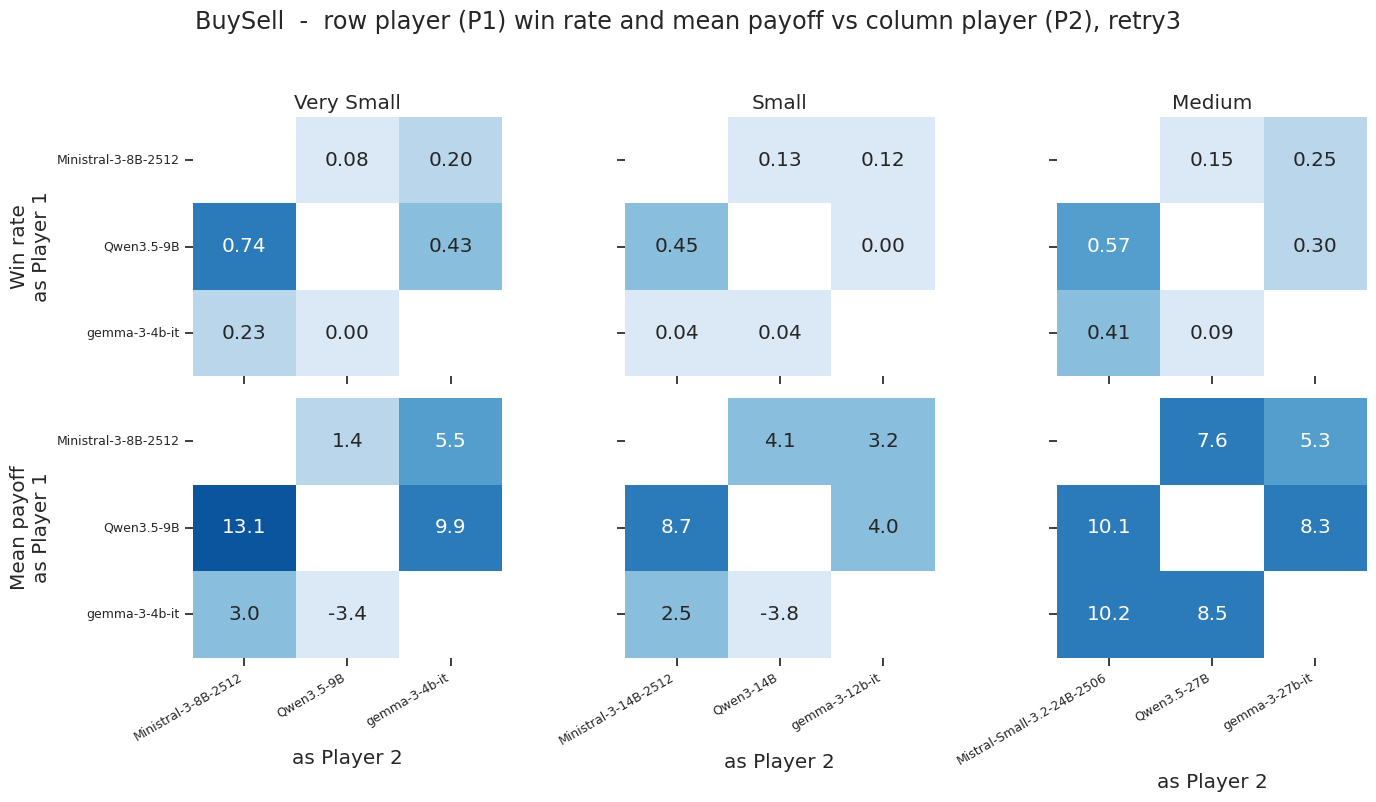

BuySell Very Small  -  wins k/n, ties excluded (row = P1):
model_2             Ministral-3-8B-2512 Qwen3.5-9B gemma-3-4b-it
model_1                                                         
Ministral-3-8B-2512                   -       2/24          3/15
Qwen3.5-9B                        17/23          -          6/14
gemma-3-4b-it                      3/13       0/26             - 

BuySell Small  -  wins k/n, ties excluded (row = P1):
model_2              Ministral-3-14B-2512 Qwen3-14B gemma-3-12b-it
model_1                                                           
Ministral-3-14B-2512                    -      3/23           3/26
Qwen3-14B                            9/20         -           0/20
gemma-3-12b-it                       1/26      1/25              - 

BuySell Medium  -  wins k/n, ties excluded (row = P1):
model_2                    Mistral-Small-3.2-24B-2506 Qwen3.5-27B gemma-3-27b-it
model_1                                                                         
Mistra

In [1021]:
pairwise_panel("BuySell")

#### Do sellers anchor the price?

The paper found the opening offer anchors the final price (Spearman ρ = 0.716 for GPT-4). Each point is one deal; the dotted line is opening = final.

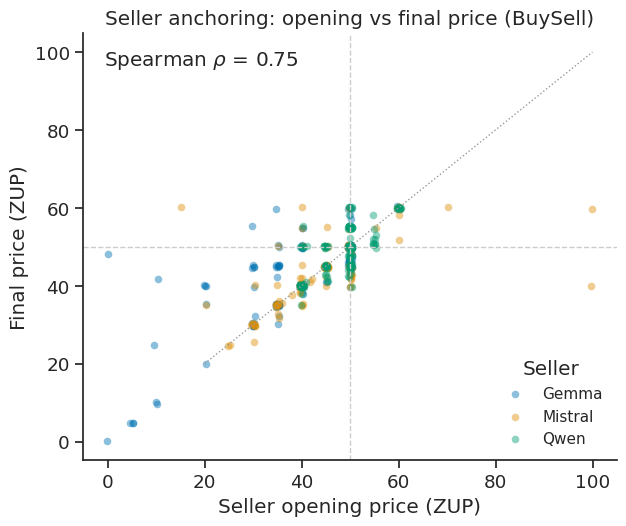

pooled Spearman rho = 0.752 (p = 6.9e-95, n = 515)
  Gemma sellers: rho = 0.718 (n = 165), mean opening 40.2 -> mean final 43.0
  Mistral sellers: rho = 0.784 (n = 170), mean opening 45.0 -> mean final 44.7
  Qwen sellers: rho = 0.681 (n = 180), mean opening 48.5 -> mean final 49.0


In [1022]:
#  P5a: anchoring -- seller opening price vs final agreed price 
bs = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["completed"]].copy()
bs["opening"] = bs["prices"].map(lambda p: p[0] if p and p[0] is not None else np.nan)
deals = bs[bs["deal"] & bs["price"].between(0, 100) & bs["opening"].between(0, 200)]

rho, pval = sps.spearmanr(deals["opening"], deals["price"])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
rng = np.random.default_rng(0)
for fam in FAMILIES:
    sub = deals[deals["family_1"] == fam]
    ax.scatter(sub["opening"] + rng.uniform(-.4, .4, len(sub)),
               sub["price"] + rng.uniform(-.4, .4, len(sub)),
               s=30, alpha=0.45, color=pal[fam], label=fam, lw=0)
lims = [20, 100]
ax.plot(lims, lims, color="0.6", lw=1, ls=":")
ax.axhline(50, ls="--", color="0.8", lw=1); ax.axvline(50, ls="--", color="0.8", lw=1)
ax.text(0.04, 0.96, f"Spearman $\\rho$ = {rho:.2f}", transform=ax.transAxes, va="top")
ax.set_xlabel("Seller opening price (ZUP)"); ax.set_ylabel("Final price (ZUP)")
ax.legend(title="Seller", loc="lower right", fontsize=11)
ax.set_title('Seller anchoring: opening vs final price (BuySell)')
fig.tight_layout(); plt.show()

print(f"pooled Spearman rho = {rho:.3f} (p = {pval:.1e}, n = {len(deals)})")
for fam in FAMILIES:
    sub = deals[deals["family_1"] == fam]
    r, p = sps.spearmanr(sub["opening"], sub["price"])
    print(f"  {fam} sellers: rho = {r:.3f} (n = {len(sub)}), "
          f"mean opening {sub.opening.mean():.1f} -> mean final {sub.price.mean():.1f}")

#### Do they make irrational moves?

Two moves are irrational by construction: a seller offering below its own cost of 40, and a buyer offering above its value of 60. Rates per game in that role (seller columns: family as P1; buyer columns: family as P2).

In [1023]:
#  P5c: irrational moves 
def seller_offers(p): return [x for x in (p or [])[0::2] if x is not None]
def buyer_offers(p):  return [x for x in (p or [])[1::2] if x is not None]

bs["seller_open_below_cost"] = bs["prices"].map(
    lambda p: p[0] is not None and p[0] < 40 if p else np.nan)
bs["seller_any_below_cost"] = bs["prices"].map(
    lambda p: any(x < 40 for x in seller_offers(p)) if seller_offers(p) else np.nan)
bs["buyer_any_above_value"] = bs["prices"].map(
    lambda p: any(x > 60 for x in buyer_offers(p)) if buyer_offers(p) else np.nan)
bs["deal_seller_loss"] = np.where(bs["deal"], bs["price"] < 40, np.nan)
bs["deal_buyer_loss"] = np.where(bs["deal"], bs["price"] > 60, np.nan)

seller_side = (bs.groupby(["size", "family_1"])
               [["seller_open_below_cost", "seller_any_below_cost", "deal_seller_loss"]]
               .mean())
buyer_side = (bs.groupby(["size", "family_2"])
              [["buyer_any_above_value", "deal_buyer_loss"]].mean())
irr = seller_side.join(buyer_side.rename_axis(seller_side.index.names)).round(3)
irr.index.names = ["size", "family"]
irr = irr.reindex(SIZES, level=0)
display(irr)

print("Rates are per game in that role (seller cols: family as P1; buyer cols: family as P2).")
print(f"\nOverall: sellers open below their own cost in {bs.seller_open_below_cost.mean():.1%} "
      f"of games; {bs.deal_seller_loss.mean():.1%} of deals close below cost "
      f"(seller loss), {bs.deal_buyer_loss.mean():.1%} above 60 (buyer loss).")

seller_open_below_cost seller_any_below_cost  \
size       family                                                  
very_small Gemma                     0.212               0.22449   
           Mistral                   0.220              0.237288   
           Qwen                      0.000                   0.0   
small      Gemma                     0.767              0.783333   
           Mistral                   0.267              0.288136   
           Qwen                      0.000              0.033333   
medium     Gemma                     0.000                   0.0   
           Mistral                   0.000              0.083333   
           Qwen                      0.000                   0.0   

                    deal_seller_loss buyer_any_above_value  deal_buyer_loss  
size       family                                                            
very_small Gemma               0.188              0.111111              0.0  
           Mistral             0.189                   0.0              0.0  
           Qwen                0.000                   0.0              0.0  
small      Gemma               0.467                   0.0              0.0  
           Mistral             0.217                   0.0              0.0  
           Qwen                0.033                   0.0              0.0  
medium     Gemma               0.000                   0.0              0.0  
           Mistral             0.086                   0.0              0.0  
           Qwen                0.000                   0.0              0.0

Rates are per game in that role (seller cols: family as P1; buyer cols: family as P2).

Overall: sellers open below their own cost in 16.2% of games; 12.9% of deals close below cost (seller loss), 0.0% above 60 (buyer loss).


#### Buyer vs seller: who captures the surplus?

NegotiationArena reported the final price sits **below** the 50 midpoint and that LLMs do better as
**buyers** than as sellers. In our setup P1 is the seller (cost 40) and P2 the buyer (value 60), so
a deal at price $p$ gives the seller $p-40$ and the buyer $60-p$.

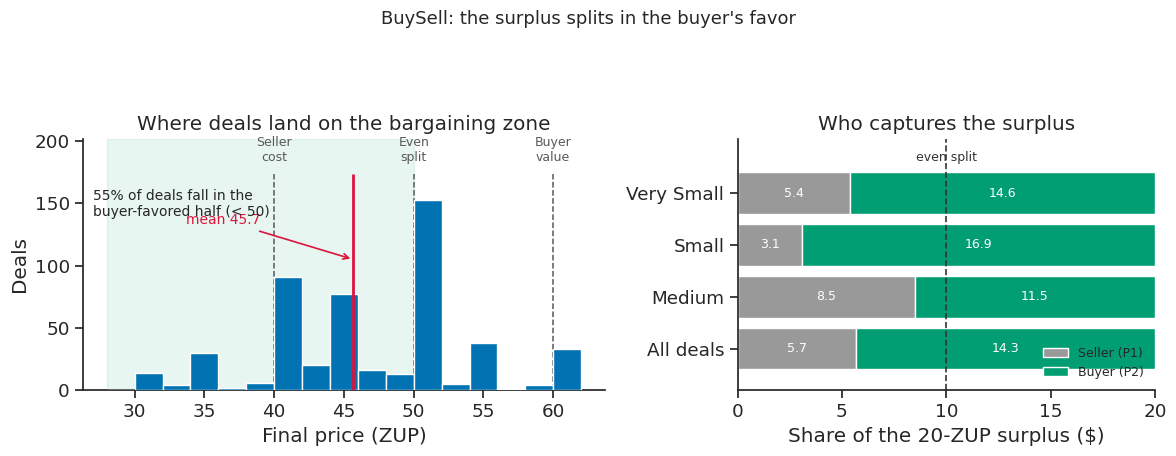

Deals below midpoint: 54.8%; exactly 50: 28.8%; mean price 45.7
Mean surplus -- seller 5.7  buyer 14.3 (of 20 total)


In [1024]:
#  B1: how the fixed 20-ZUP surplus on the [40,60] bargaining zone gets divided
bsd = bs[bs["deal"] & bs["price"].between(0, 100)].copy()
seller_c = "0.6"
buyer_c = sns.color_palette("colorblind")[2]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.25, 1]})

# -- left: where deals land on the seller(40)->buyer(60) bargaining zone --
counts, _, _ = axL.hist(bsd["price"], bins=np.arange(28, 63, 2),
                        color=sns.color_palette("colorblind")[0], edgecolor="white", zorder=3)
top = counts.max() * 1.32
axL.set_ylim(0, top)
axL.axvspan(28, 50, color=buyer_c, alpha=0.09, zorder=0)        # buyer-favored half (< 50)
line_top = top * 0.86
for xv, lab in [(40, "Seller\ncost"), (50, "Even\nsplit"), (60, "Buyer\nvalue")]:
    axL.vlines(xv, 0, line_top, ls="--", color="0.35", lw=1.1, zorder=2)
    axL.text(xv, top * 0.90, lab, ha="center", va="bottom", fontsize=9, color="0.35")
mp = bsd["price"].mean(); pct_below = (bsd["price"] < 50).mean()
axL.vlines(mp, 0, line_top, color="crimson", lw=2, zorder=4)
axL.annotate(f"mean {mp:.1f}", xy=(mp, top * 0.52), xytext=(mp - 12, top * 0.66),
             color="crimson", fontsize=10,
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
axL.text(0.02, 0.80, f"{pct_below:.0%} of deals fall in the\nbuyer-favored half (< 50)",
         transform=axL.transAxes, va="top", fontsize=10)
axL.set_xlabel("Final price (ZUP)"); axL.set_ylabel("Deals")
axL.set_title("Where deals land on the bargaining zone")

# -- right: mean split of the 20-ZUP surplus, seller vs buyer (sums to 20 by construction) --
groups = [("Very Small", "very_small"), ("Small", "small"),
          ("Medium", "medium"), ("All deals", None)]
y = np.arange(len(groups))[::-1]
sell = [(bsd if k is None else bsd[bsd["size"] == k])["payoff_1"].mean() for _, k in groups]
buy = [(bsd if k is None else bsd[bsd["size"] == k])["payoff_2"].mean() for _, k in groups]
axR.barh(y, sell, color=seller_c, label="Seller (P1)")
axR.barh(y, buy, left=sell, color=buyer_c, label="Buyer (P2)")
for yi, s, b in zip(y, sell, buy):
    axR.text(s / 2, yi, f"{s:.1f}", ha="center", va="center", color="white", fontsize=9)
    axR.text(s + b / 2, yi, f"{b:.1f}", ha="center", va="center", color="white", fontsize=9)
axR.axvline(10, ls="--", color="0.2", lw=1.2)                  # even (10/10) split of 20
axR.text(10, len(groups) - 0.45, "even split", ha="center", va="bottom", fontsize=9, color="0.2")
axR.set_ylim(-0.8, len(groups) + 0.05)
axR.set_yticks(y); axR.set_yticklabels([g for g, _ in groups])
axR.set_xlim(0, 20); axR.set_xlabel("Share of the 20-ZUP surplus ($)")
axR.set_title("Who captures the surplus")
axR.legend(loc="lower right", fontsize=9)
fig.suptitle("BuySell: the surplus splits in the buyer's favor", y=1.04, fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

print(f"Deals below midpoint: {pct_below:.1%}; exactly 50: {(bsd['price'] == 50).mean():.1%}; "
      f"mean price {mp:.1f}")
print(f"Mean surplus -- seller {bsd['payoff_1'].mean():.1f}  buyer {bsd['payoff_2'].mean():.1f} "
      f"(of 20 total)")

<!-- INSIGHTS_BUYSELL -->
**Insights**

- **Anchoring replicates at GPT-4 magnitude.** The final price correlates strongly with the
  seller's opening offer (Spearman ρ = 0.75, n ≈ 515 deals; the paper reports ρ = 0.716 for
  GPT-4). Opening policies are family signatures: Qwen sellers anchor high (mean opening 48.5 →
  final 49.0) while Gemma opens at its own cost (40.2 → final 43.0), conceding the surplus before
  negotiation begins.
- **Buyer advantage + split-the-difference (Fig. B1).** 55% of deals close below the 50 midpoint and
  29% land exactly on 50; the midpoint is a strong focal point. The buyer captures the larger share —
  mean surplus 14.3\$ for the buyer vs 5.7\$ for the seller — directly replicating NegotiationArena's
  "LLMs do better as buyers than sellers."
- **Irrationality is concentrated and asymmetric.** gemma-3-12b-it opens below its own cost in
  77% of its seller games and 47% of its deals close at a seller loss; Qwen sellers essentially
  never do either (0–3%). Buyers, by contrast, *never close a deal* above their value of 60 (a few do
  propose above it, but none is ever accepted), so realised losses are purely a
  seller phenomenon, mirroring the paper's finding that LLMs do better
  as buyers than as sellers.

### Replication scorecard vs NegotiationArena

A claim-by-claim summary: which of NegotiationArena's frontier-model findings reappear in
open-weight cross-play. ✓ = same direction and magnitude; *analog* = same qualitative pattern but
not directly comparable (different models).

In [1025]:
#  Scorecard: NegotiationArena claim vs open-weight result (numbers recomputed inline)
def _p1_winrate(game):
    d = RETRY3[(RETRY3["game"] == game) & RETRY3["winner"].isin(["P1", "P2"])]
    return (d["winner"] == "P1").mean()

# BuySell anchoring rho (opening -> final)
_an = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["deal"]].copy()
_an["opening"] = _an["prices"].map(lambda p: p[0] if p and p[0] is not None else np.nan)
_an = _an[_an["price"].between(0, 100) & _an["opening"].between(0, 200)]
rho_bs, _ = sps.spearmanr(_an["opening"], _an["price"])

# BuySell price vs midpoint + buyer/seller surplus
_bd = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["deal"] & RETRY3["price"].between(0, 100)]
below = (_bd["price"] < 50).mean()
seller_m, buyer_m = _bd["payoff_1"].mean(), _bd["payoff_2"].mean()

# Ultimatum opening offer by tier
_u = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["completed"]]
_u = _u[_u["ult_open_offer"].between(0, 100)]
open_by_tier = _u.groupby("size")["ult_open_offer"].mean().reindex(SIZES)

scorecard = pd.DataFrame([
    ["Ultimatum: proposer (P1) almost always wins", "P1 dominates",
     f"P1 win {_p1_winrate('Ultimatum'):.0%}", "✓"],
    ["Trading: second-mover advantage", "P1 often loses",
     f"P1 win {_p1_winrate('Trading'):.0%}", "✓"],
    ["BuySell: second-mover advantage", "P1 often loses",
     f"P1 win {_p1_winrate('BuySell'):.0%}", "✓"],
    ["BuySell anchoring (opening → final, Spearman ρ)", "ρ = 0.716 (GPT-4)",
     f"ρ = {rho_bs:.2f}", "✓"],
    ["BuySell final price below the 50 midpoint", "< 50 typical",
     f"{below:.0%} below 50", "✓"],
    ["LLMs do better as buyer than seller", "buyer advantage",
     f"buyer {buyer_m:.1f}$ vs seller {seller_m:.1f}$", "✓" if buyer_m > seller_m else "✗"],
    ["Ultimatum: stronger models open lower", "Claude −10$ vs GPT",
     f"{open_by_tier.min():.0f}–{open_by_tier.max():.0f}$ across tiers", "analog"],
], columns=["NegotiationArena claim", "Their result", "Open-weight result", "Replicates?"])
display(scorecard.style.hide(axis="index"))

NegotiationArena claim,Their result,Open-weight result,Replicates?
Ultimatum: proposer (P1) almost always wins,P1 dominates,P1 win 91%,✓
Trading: second-mover advantage,P1 often loses,P1 win 25%,✓
BuySell: second-mover advantage,P1 often loses,P1 win 23%,✓
"BuySell anchoring (opening → final, Spearman ρ)",ρ = 0.716 (GPT-4),ρ = 0.75,✓
BuySell final price below the 50 midpoint,< 50 typical,55% below 50,✓
LLMs do better as buyer than seller,buyer advantage,buyer 14.3$ vs seller 5.7$,✓
Ultimatum: stronger models open lower,Claude −10$ vs GPT,15–35$ across tiers,analog


<!-- CONCLUSIONS -->
## 5. Conclusions

Takeaways for Chapter 4 §4.1, each grounded in the numbers above:

1. **Self-Correction Works.** Completion without self-correction is an inverted-U in
   size (medium Trading 0.678) and a 3-retry budget restores ≥ 0.99 almost everywhere for ≈0.36
   extra generations per game. 
2. **Family rankings remain across scales.** The pooled ranking Qwen
   (0.63–0.67) > Gemma (≈0.45) > Mistral (0.38–0.43) is identical in all three tiers; 4B → 27B
   scaling never reorders it. In the Trading and BuySell games Qwen is the winner, while in the
   Ultimatum game Gemma is the winner.
3. **Role asymmetry remains.** Proposer dominance in Ultimatum
   (0.86–0.97) and second-mover advantage in Trading/BuySell (P1 wins only 0.12–0.33) exists in open-weight models, replicating NegotiationArena's GPT-4 finding.
4. **Ultimatum proposers anchor, and aggression scales.** Open-weight proposers offer the responder
   far below an even split (mean ≈27\$ of 100), and the opening offer separates families and tiers
   just as Claude opened below GPT in the original study.
5. **Buyer advantage and sub-midpoint prices replicate.** BuySell deals close below the 50 midpoint
   and the buyer (P2) captures more surplus than the seller (P1), matching NegotiationArena's
   frontier-model result. The replication scorecard above collects every comparison in one place.